## Problem Statement

### Business Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

*   To identify the segment of potential customers who have a higher probability of purchasing the loan.

*   To understand which customer attributes are most significant in driving purchases, and target those customers to drive more business.

*  To build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.







### Data Dictionary


- ID: Customer ID
- Age: Customer’s age in completed years
- Experience: # years of professional experience
- Income: Annual income of the customer (in thousand dollars)
- ZIP Code: Home Address ZIP code.
- Family: The family size of the customer
- CCAvg: Average spending on credit cards per month (in thousand dollars)
- Education: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
- Mortgage: Value of house mortgage if any. (in thousand dollars)
- Personal_Loan: Did this customer accept the personal loan offered in the last campaign?
- Securities_Account: Does the customer have a securities account with the bank?
- CD_Account: Does the customer have a certificate of deposit (CD) account with the bank?
- Online: Do customers use Internet banking facilities?
- CreditCard: Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

# **Installing and Importing the necessary libraries**

In [ ]:
#!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 -q

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# loading the dataset
loan_data = pd.read_csv("Loan_Modelling.csv")

In [ ]:
# copying the data to another variable to avoid any changes to original data
df = loan_data.copy()

## Data Overview

### Checking the shape of the data

In [ ]:
df.shape

(5000, 14)

* The dataset has 5000 rows and 14 columns

### Displaying the first few rows of the data

In [ ]:
# viewing the first few rows
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
df.sample(20)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
82,83,41,16,82,92507,1,4.0,3,0,0,0,0,1,0
4830,4831,37,12,60,95616,4,2.1,3,217,0,0,0,1,0
4109,4110,27,0,30,93107,4,1.0,3,0,0,0,0,1,1
4240,4241,39,14,161,95064,1,4.1,1,509,0,1,0,0,0
246,247,38,14,60,94025,2,0.6,3,0,0,0,0,1,1
1647,1648,35,5,68,90509,4,1.8,3,0,0,0,0,0,0
2311,2312,62,37,115,90245,4,3.4,2,0,0,0,0,1,1
563,564,51,27,12,94608,4,1.0,1,0,0,0,0,1,0
4586,4587,58,32,61,91910,3,2.2,3,0,0,0,0,1,1
1794,1795,56,32,98,91355,3,3.9,3,0,1,0,0,0,0


In [ ]:
# fixing column names
df.columns = [c.replace(" ", "_") for c in df.columns]

### Checking the data types of the columns for the dataset.

In [ ]:
# let's look at the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


**Observations**:

- We observe that there are no null values in the data set.

- We see that all the columns are numeric and there are no categorical columns.

- Eventhough we see the columns **Personal_Loan, Securities_Account, CD_Account, Online, CreditCard, Family, Education** seems to be numeric in the data, but they are categorical variabels by nature, which have been encoded by default in the dataset. So we don't need to convert them seperately.

- Columns **ID** and **ZIPCode** are not more meaningful for our analysis, so we can drop them.   

- We can keep ZipCode now because there are certain observations which are idnetified unique by ZipCode. If we drop ZIPCode, we may lose some data and later during the analysis we may see the model biased. So lets not drop the column and will keep in analysis.


In [ ]:
# Currently we are dropping only ID Column.
df.drop("ID", axis=1, inplace=True)

In [ ]:
# Check the info of data set after dropping the columns
# We see the columns are now dropped from data set.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


### Checking for duplicate values

In [ ]:
# let's check for duplicate observations
df.duplicated().sum()

np.int64(0)

- There are no duplicates in the data set.

### Checking the Statistical Summary

Let's take a look at the summary of the data

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


**Observations:**

- **Age and Experience:** The mean age is around 45 years, mean for experience  is around 20 years.
The minimum experience is **-3** years, which is likely an data entry error or anomaly that might need further investigation or handling.

- **Income and CCAvg:** The average income is about 73.8k, with a wide range (8k to 224k).
The average credit card spending (CCAvg) is around 1.9k per month, also with a significant range (0 to 10k).


- **Family:** The average family size is about 2.4, with a range from 1 to 4.
- **Mortgage:** The average mortgage value is around 56.5k, but the maximum is much higher at 635k, and the 75th percentile is only 101k, indicating there is  a skewness in the distribution with many customers having no mortgage (min is 0).
- **Personal_Loan:** Only 9.6% of customers accepted a personal loan, indicating that personal loan uptake is relatively low in this dataset.
- **Securities_Account:** About 10.4% of customers have a securities account with the bank.
- **CD_Account:** Only about 6% of customers have a certificate of deposit (CD) account with the bank.
- **Online:** A significant majority, nearly 60%, of customers use Internet banking facilities.
- **CreditCard:** About 29.4% of customers use a credit card issued by another bank.

- **Education:** The education levels are represented by integers 1, 2, and 3. The mean of 1.88 suggests a distribution skewed towards undergraduate and graduate levels.

### Checking for missing values

In [ ]:
# checking missing values
df.isna().sum()

,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0
Securities_Account,0


- There are no missing values in the data.

## Exploratory Data Analysis

### Univariate Analysis

In [ ]:
# In the data set, we see all the columns are numeric, So selet only varialbles which are meaningful.
# Exclude ZIPCode, segregate all Numeric and Categorical variables for plotting appropriate plots .

# selecting numerical columns
all_features = df.select_dtypes(include=np.number).columns.tolist()

#For Visualization, we dont need the ZipCode. So no considering the column.
all_features.remove('ZIPCode')

# Categorical Columns: Personal_Loan, Securities_Account, CD_Account, Online, CreditCard, Family, Education
Cat_features = ["Personal_Loan", "Securities_Account", "CD_Account", "Online", "CreditCard", "Family", "Education"]

#Numeric columns: Age , Experience, Income,  CCAvg,  Mortgage
# defining the list of numerical features to plot
num_features = [col for col in all_features if col not in Cat_features]

print('All Features: ' + str(all_features))
print('Numerical Features: ' + str(num_features))
print('Categorical Features: ' + str(Cat_features))



All Features: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']
Numerical Features: ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
Categorical Features: ['Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Family', 'Education']


- We will plot Histograms, boxplots for Numeric Variabels to understand the data better.

- Bar plots for visualising the categorical variables.

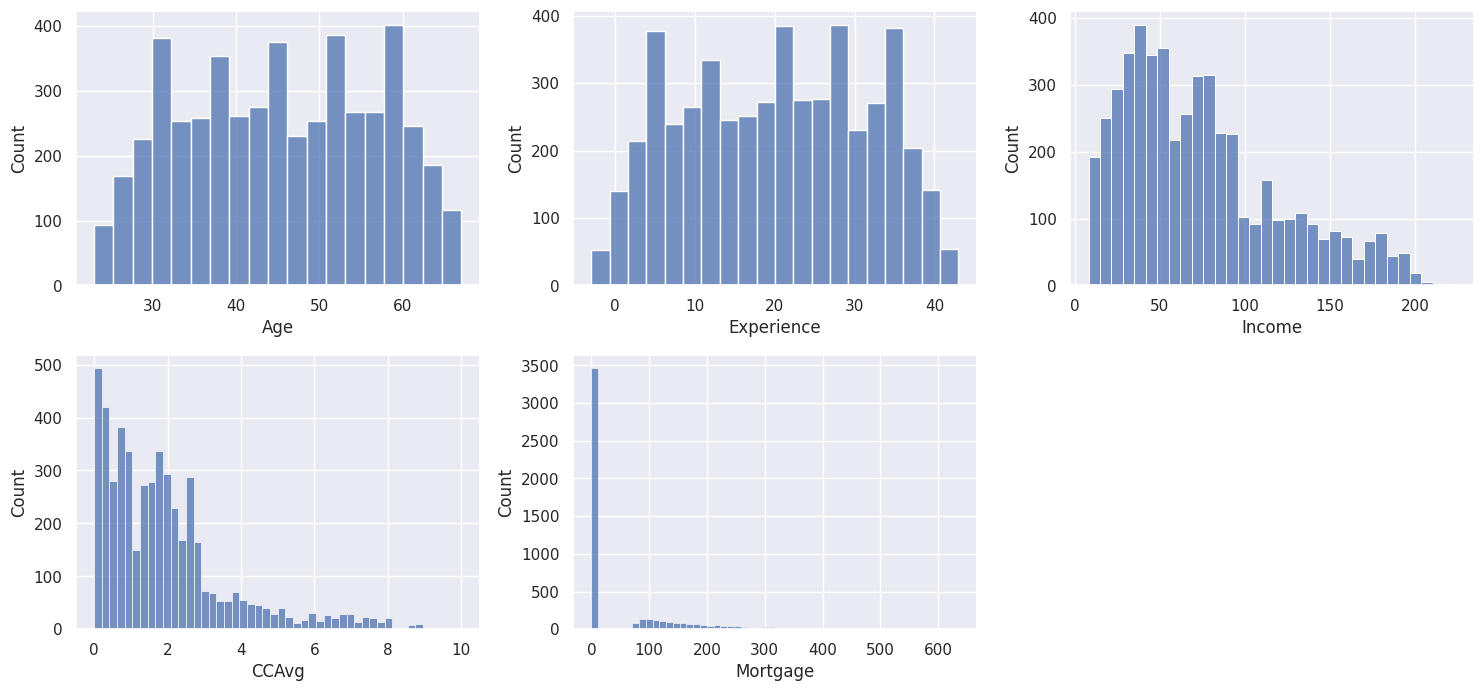

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=df, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

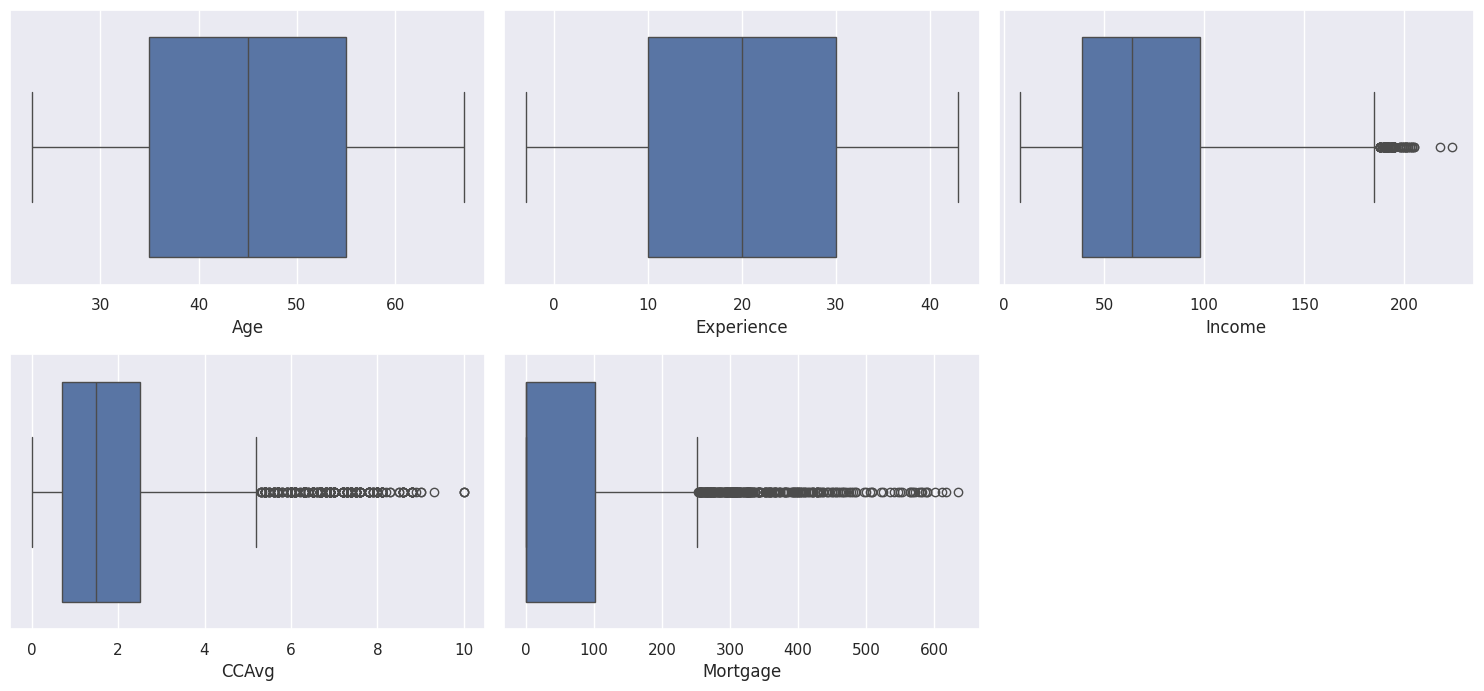

In [ ]:
#We will plot Box plots for the numeric features
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=df, x=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

**Observations from Numeric variables Analysis:**

- **Age:** The distribution of age is almost uniform , with a slight peak in the younger age groups and then a gradual decrease in older age groups. There are no outliers.

- **Experience:** Similar to Age, the experience distribution also seems to be  uniform, but there are some data points with negative experience, which are likely errors and need to be handled.

- **Income:** The income distribution is right-skewed, with a large number of customers having lower incomes and a smaller number of customers with very high incomes (outliers).

- **CCAvg:** The average credit card spending is also right-skewed, with many of the customers having low average spending and a few customers with very high spending. There are some outliers with very high CCAvg values.

- **Mortgage:** The mortgage value is highly right-skewed, with a large number of customers having no mortgage (value 0) and a few with very high mortgage values (outliers).


In [ ]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

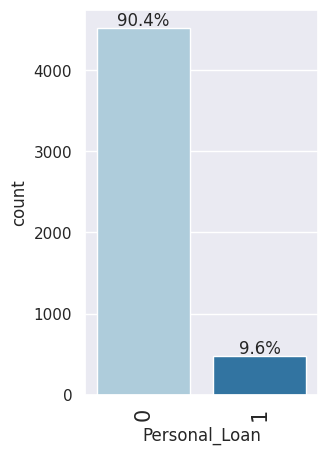

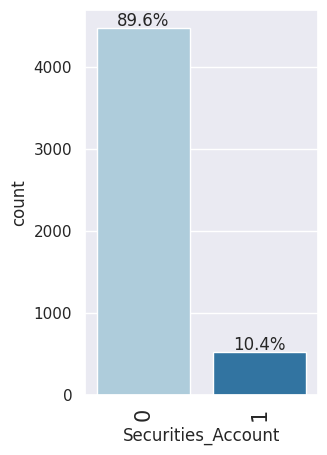

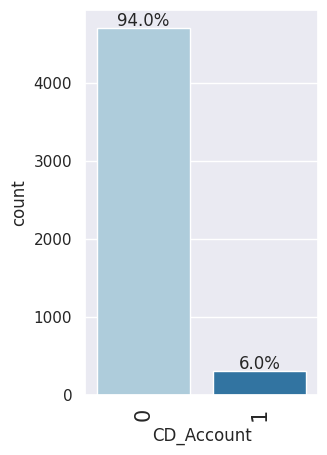

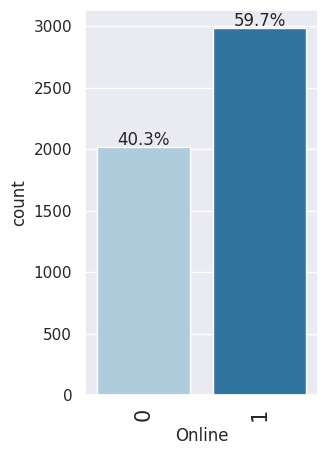

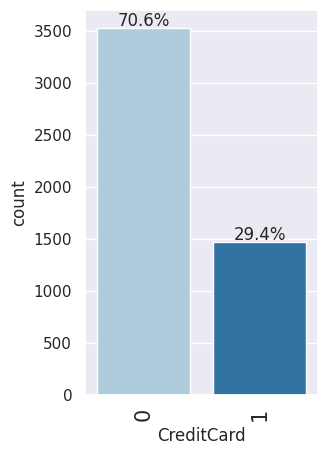

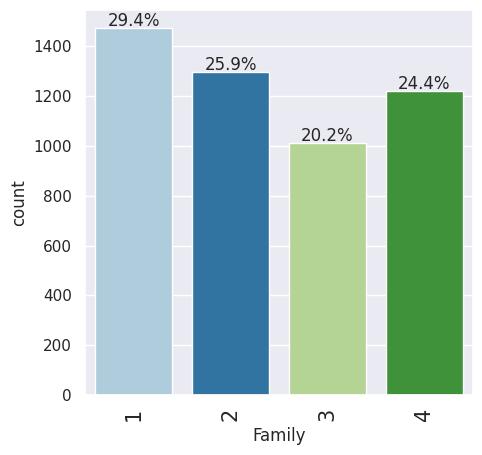

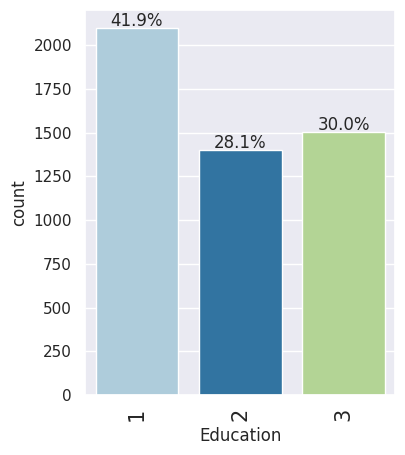

In [ ]:
# Bar plots visualization
for col in Cat_features:
    labeled_barplot(df, col, perc=True)

**Observations from Categorical Variables:**

- **Personal_Loan:**
1.   A small percentage (9.6%) of customers accepted the personal loan offer.  We see majority of the customers have not taken personal loan(90.4%).
2.   This indicates an imbalanced dataset for the target variable.The bar plot clearly shows two categories: 0 (did not accept loan) and 1 (accepted loan).

3. This data imbalance is problamatic while building the model. we need to apply class weighting to prevent the modle from becoming biased towards the major class (Class 0 - Did not accept the loan).

- **Securities_Account:**

1. The majority of customers do not have a securities account.

2. Around 89.6% of customers do not have a securities account, while 10.4% do have one.

- **CD_Account:**

1. A very small portion of customers have a CD account.

2. Approximately 94% of customers do not have a CD account, and only 6% do have one.

- **Online:**
1.  Internet banking usage is fairly widespread.

2. About 40.3% of customers do not use internet banking, while 59.7% do use it.

3. This shows the digial engagement of Customers for bank products.  

- **CreditCard:**
1.  The majority of customers do not use a credit card issued by another bank.

2. Around 70.6% of customers do not use a credit card from another bank, and 29.4% do.

3. Customers without other bank credit cards might be more open to AllLife Bank's loan products, or conversely, those with other cards might be more financially active in general.

- **Family:**

1. Family sizes are distributed across 1, 2, 3, and 4. The most common family sizes are 1 and 2, followed by 3 and 4.

    *   Family size 1: ~29.5%
    *   Family size 2: ~26.4%
    *   Family size 3: ~20.0%
    *   Family size 4: ~24.1%
2. Family size can have a good  correlation with financial needs and responsibilities. Larger families might have different loan requirements or repayment capabilities, making this an important demographic feature.

- **Education:**
1. Education levels are divided into three categories: 1 (Undergrad), 2 (Graduate), and 3 (Advanced/Professional). The distribution is  spread well, with 'Undergrad' and 'Advanced/Professional' being slightly more prevalent than 'Graduate'.

    *   Level 1 (Undergrad): ~41.9%
    *   Level 2 (Graduate): ~27.0%
    *   Level 3 (Advanced/Professional): ~31.1%

2. Education level is more crucial for Income, Loans accepting. so we can suspect that this varible with level 2, level 3 may be the good  targeted customers for Loan purchase.

### Bivariate Analysis

**Let's check for correlations.**

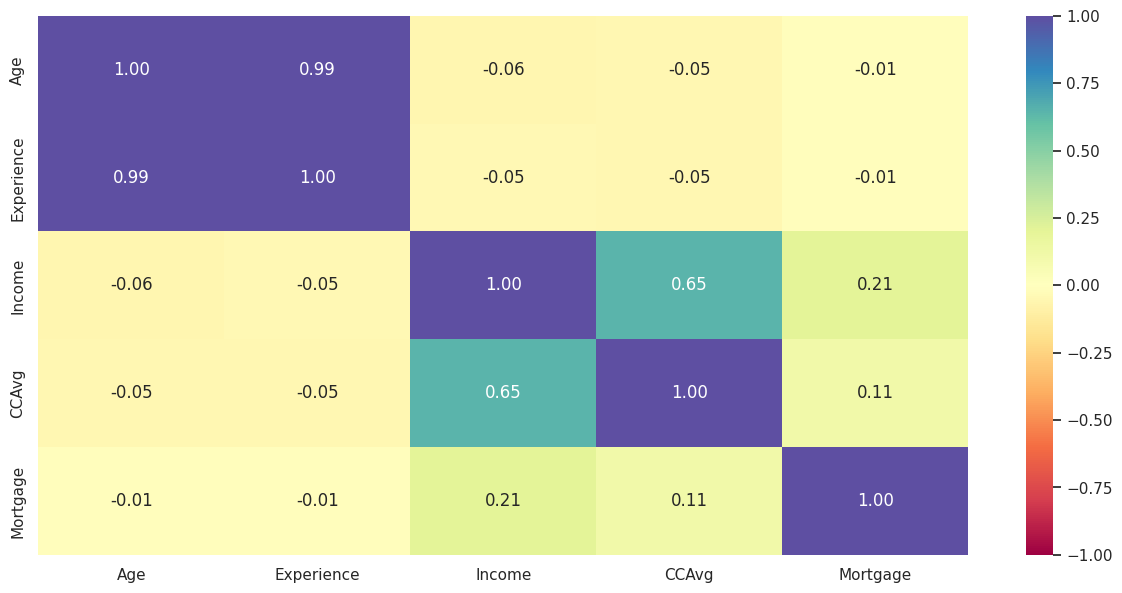

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_features].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations on numeric columns:**
  - There is a strong positive correlation  (0.99) between **Age** and **Experience**. This is expected as experience typically increases with age.

  - **Income** shows a moderate positive correlation with **CCAvg** and **Mortgage**. This suggests that customers with higher incomes tend to spend more on credit cards and have higher mortgage values.

  - There are no other strong correlations between the numerical features.



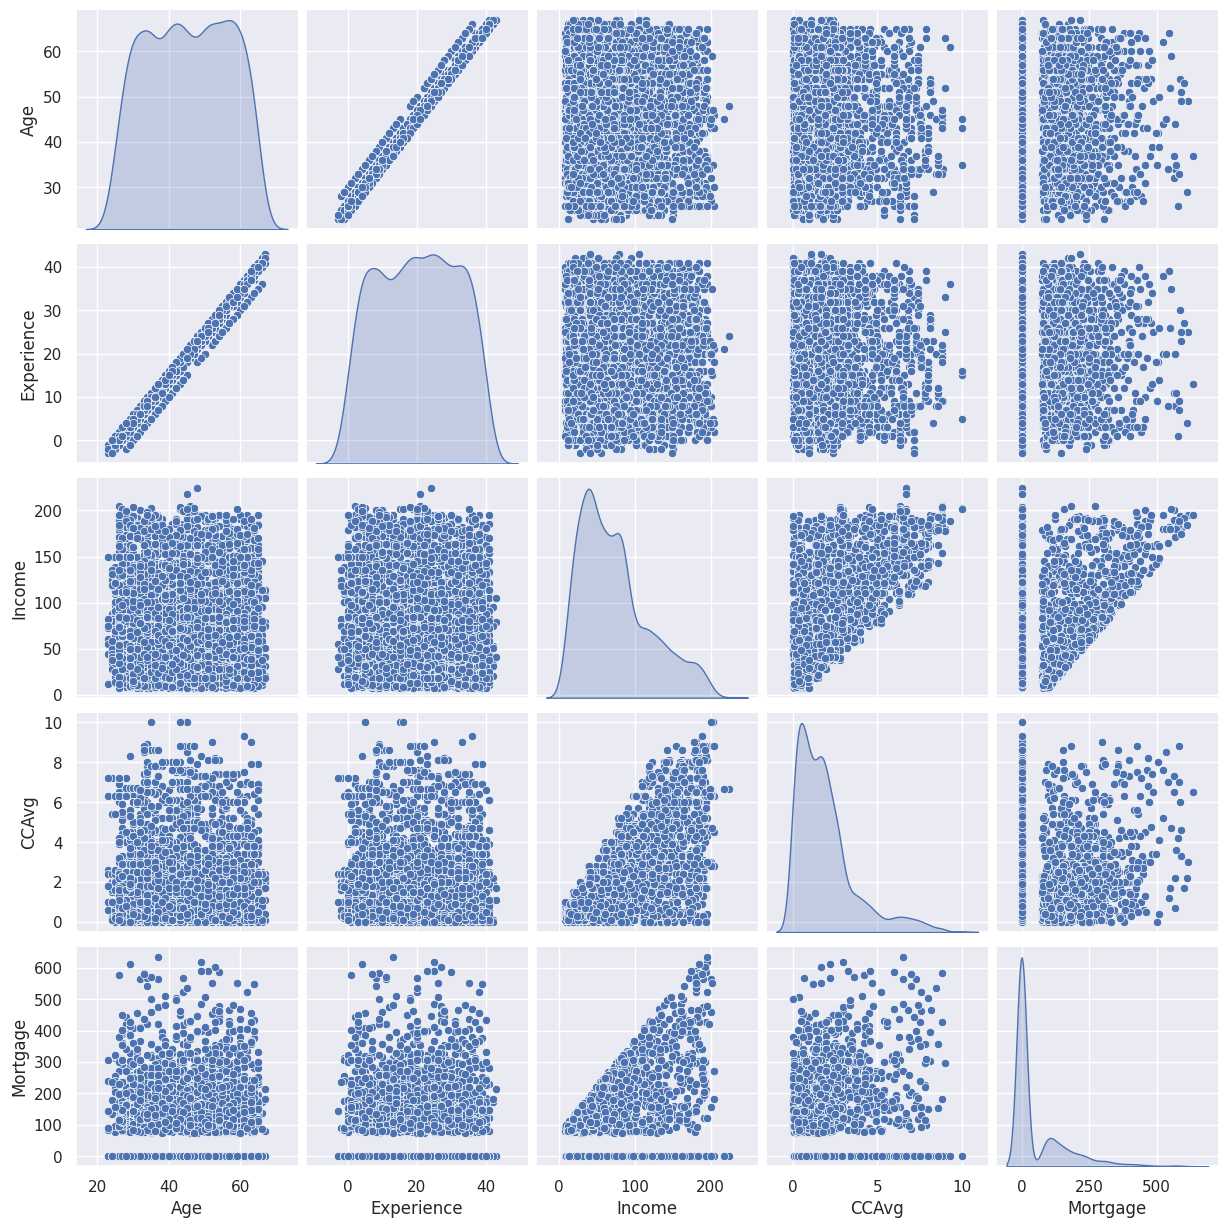

In [ ]:
sns.pairplot(data=df[num_features], diag_kind="kde")
plt.show()

**Observations:**
  - The scatter plots in the pairplot visually confirm the correlations observed in the heatmap. The relationship between **Age** and **Experience** is clearly linear.
  - The distributions on the diagonal of the pairplot are consistent with the univariate analysis, showing the skewness in **Income**, **CCAvg**, and **Mortgage**.




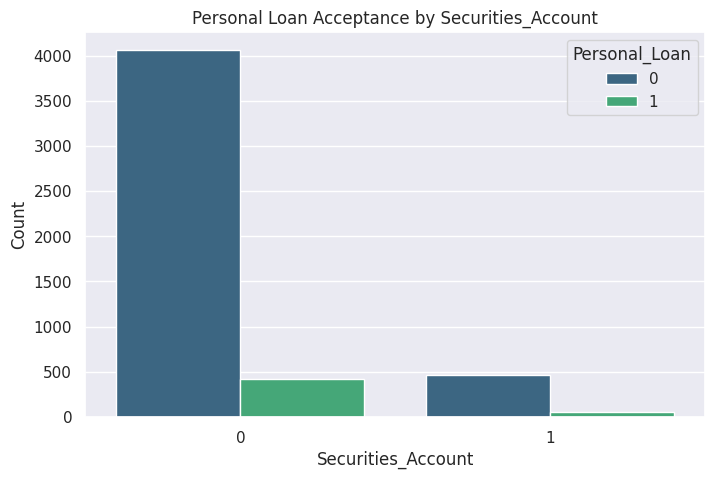

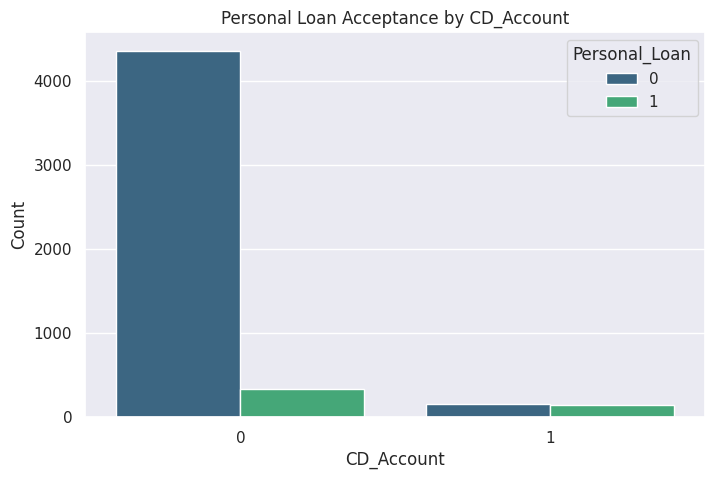

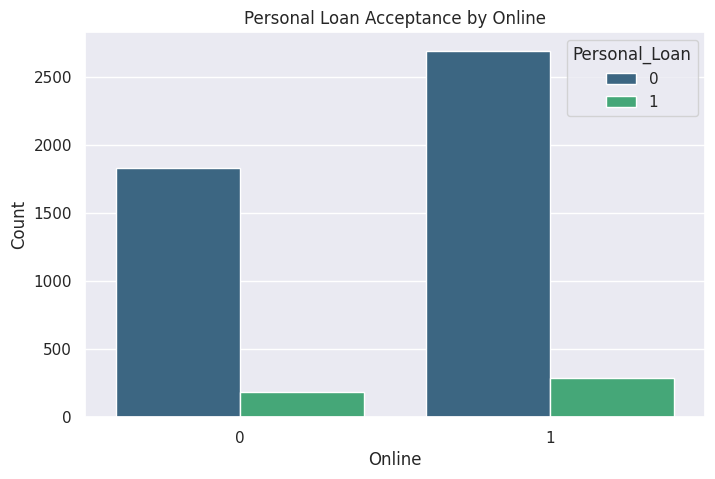

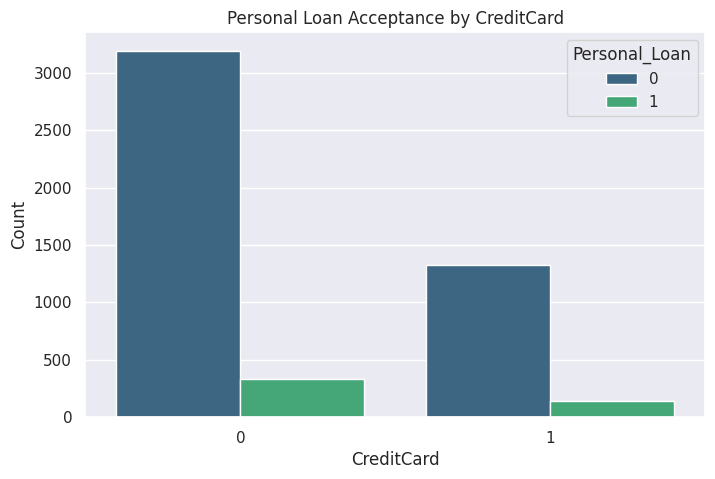

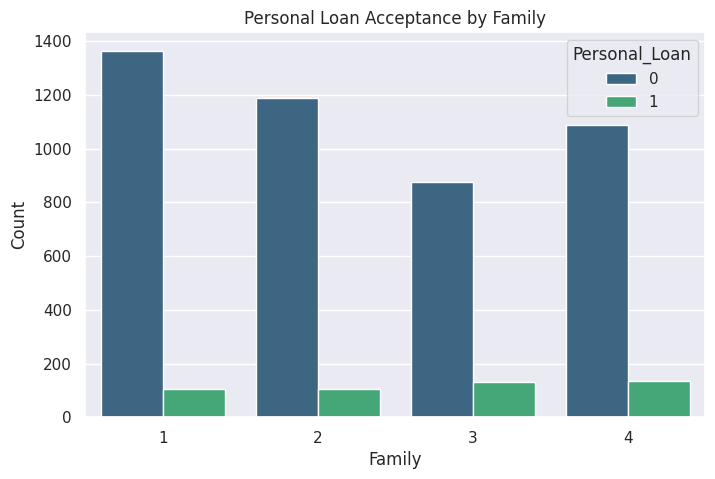

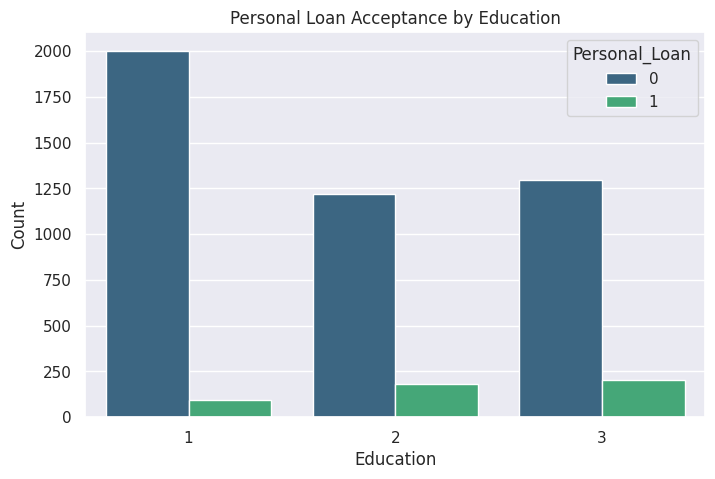

In [ ]:
#Lets explore the bivariate analysis of all categorical varibles with hue as our target varable (Personal_Loan)
cat_cols = ["Securities_Account", "CD_Account", "Online", "CreditCard", "Family", "Education"]
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue="Personal_Loan", palette="viridis")
    plt.title(f"Personal Loan Acceptance by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [ ]:
#Create crosstabs for each variable in binary_vars
for col in Cat_features:
    print(f"\nCrosstabulation of Personal_Loan and {col}:")
    display(pd.crosstab(df["Personal_Loan"], df[col], normalize='index'))


Crosstabulation of Personal_Loan and Personal_Loan:


Personal_Loan,0,1
Personal_Loan,,
0,1.0,0.0
1,0.0,1.0



Crosstabulation of Personal_Loan and Securities_Account:


Securities_Account,0,1
Personal_Loan,,
0,0.897788,0.102212
1,0.875000,0.125000



Crosstabulation of Personal_Loan and CD_Account:


...

CreditCard,0,1
Personal_Loan,,
0,0.706416,0.293584
1,0.702083,0.297917



Crosstabulation of Personal_Loan and Family:


Family,1,2,3,4
Personal_Loan,,,,
0,0.301991,0.263274,0.194027,0.240708
1,0.222917,0.220833,0.277083,0.279167



Crosstabulation of Personal_Loan and Education:


Education,1,2,3
Personal_Loan,,,
0,0.443142,0.270133,0.286726
1,0.193750,0.379167,0.427083


**Observations from Bivariate Analysis on Binary Variables:**

- **Personal_Loan vs. Securities_Account:** Customers with a securities account appear to have a slightly higher likelihood of accepting a personal loan compared to those without a securities account.

- **Personal_Loan vs. CD_Account:** Customers with a CD account show a significantly higher rate of personal loan acceptance than those without a CD account. This seems to be a strong predictor.

- **Personal_Loan vs. Online:** There is no clear strong relationship between using online banking and accepting a personal loan. The proportions of loan acceptance seems so similar for both groups.

- **Personal_Loan vs. CreditCard:** Customers who do not use a credit card issued by another bank (0) seem to have a slightly higher rate of personal loan acceptance compared to those who do (1).

- **Personal_Loan vs. Family:** The proportion of personal loan acceptance varies across different family sizes. Specifically, customers with family sizes of 2 or 3 appear to have a higher ratio to accept personal loans than those with family sizes of 1 or 4.


- **Personal_Loan vs. Education:** This is another strong indicator. Customers with an education level of 3 (Advanced/Professional) demonstrate a significantly higher personal loan acceptance rate compared to those with education levels 1 (Undergrad) or 2 (Graduate).

Based on the above observations we can derive these attributes as strong predictors.
1. **CD_Account:** This appears to be a very strong predictor, as customers with a CD account are markedly more likely to accept a personal loan.

2. **Education:** Specifically, an education level of 3 (Advanced/Professional) is highly indicative of personal loan acceptance.

3. **Family:** Certain family sizes (particularly 2 and 3) show a higher likelihood of loan acceptance, suggesting this could be a good predictor.

4. **CreditCard:** The absence of a credit card from another bank (0) also seems to be a moderate predictor for higher personal loan acceptance.

To analyze the relationship between numerical features and the 'Personal_Loan' target variable,
Let's  create box plots for each numerical feature, comparing their distributions for customers who accepted a personal loan versus those who did not.

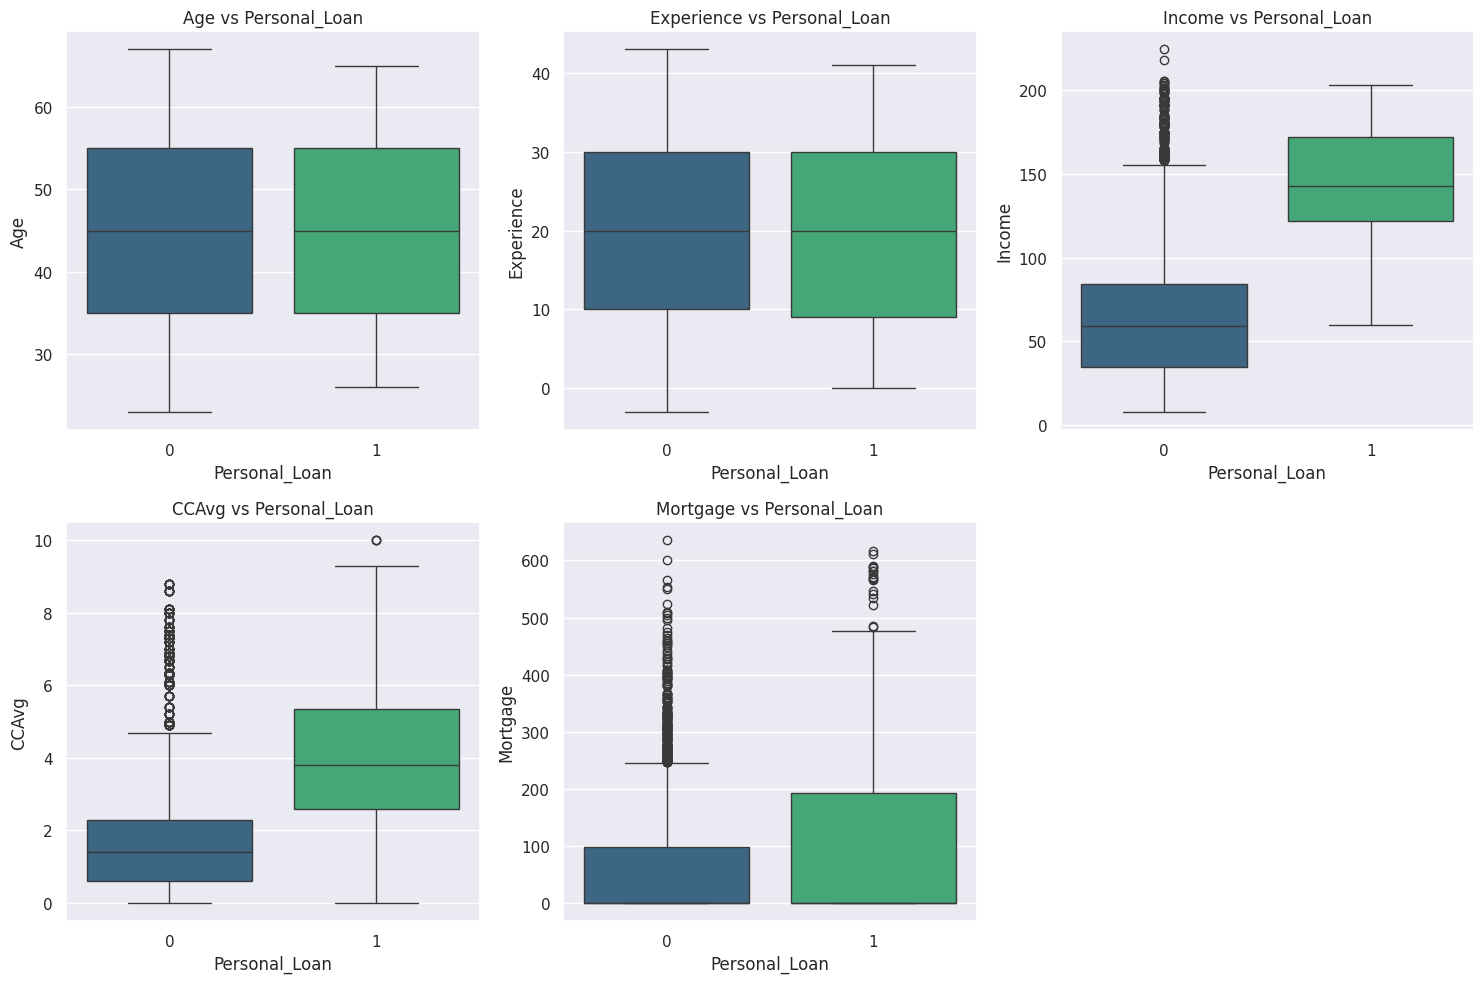

In [ ]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(num_features):
    plt.subplot(2, 3, i + 1)  # Arrange plots in a 2x3 grid
    sns.boxplot(data=df, y=feature, x='Personal_Loan', palette='viridis')
    plt.title(f'{feature} vs Personal_Loan')

plt.tight_layout()
plt.show()

### Observations from Bivariate Analysis (Numerical Features vs. Personal_Loan):

After examining the box plots comparing numerical features with `Personal_Loan` acceptance (0: No, 1: Yes):

-   **Age vs. Personal_Loan:**
    *   Age variable data seems to be normal for the both groups.

-   **Experience vs. Personal_Loan:**
    *   Similar to age, the  experience for loan acceptors seems higher. The distributions also show to be normal.
    *   The presence of negative 'Experience' values (as noted in univariate analysis) should be addressed, as this might skew the distribution.

-   **Income vs. Personal_Loan:**
    *   This feature shows a very clear difference. Customers who accepted a personal loan (`Personal_Loan` = 1) have a higher median income and a much higher overall income distribution compared to those who did not take a loan(`Personal_Loan` = 0).
    *  There are outliers in the income groups which have not accepted a personla loan(`Personal_Loan` = 0).
    *   The box plot confirms that income is a strong predictor of personal loan acceptance.

-   **CCAvg vs. Personal_Loan:**
    *   Similar to income, there's a noticeable difference in `CCAvg` (average credit card spending per month) between the two groups. Loan acceptors tend to have a higher median `CCAvg` and a higher distribution of spending.
    *   This suggests that customers with higher credit card spending habits are more likely to accept personal loans.

    * This is also a good and strong predictor of personal loan acceptance.

-   **Mortgage vs. Personal_Loan:**
    *   The distribution of `Mortgage` values also shows some distinction. A large number of customers in both groups have zero mortgage (indicated by the box starting at 0), customers who accepted a personal loan (`Personal_Loan` = 1) appear to have a higher median mortgage value and more customers with substantial mortgages.

    *   This may be because customers with higher financial commitments, such as mortgage loans or home loans, might be more inclined to take personal loans for meeting financial needs.

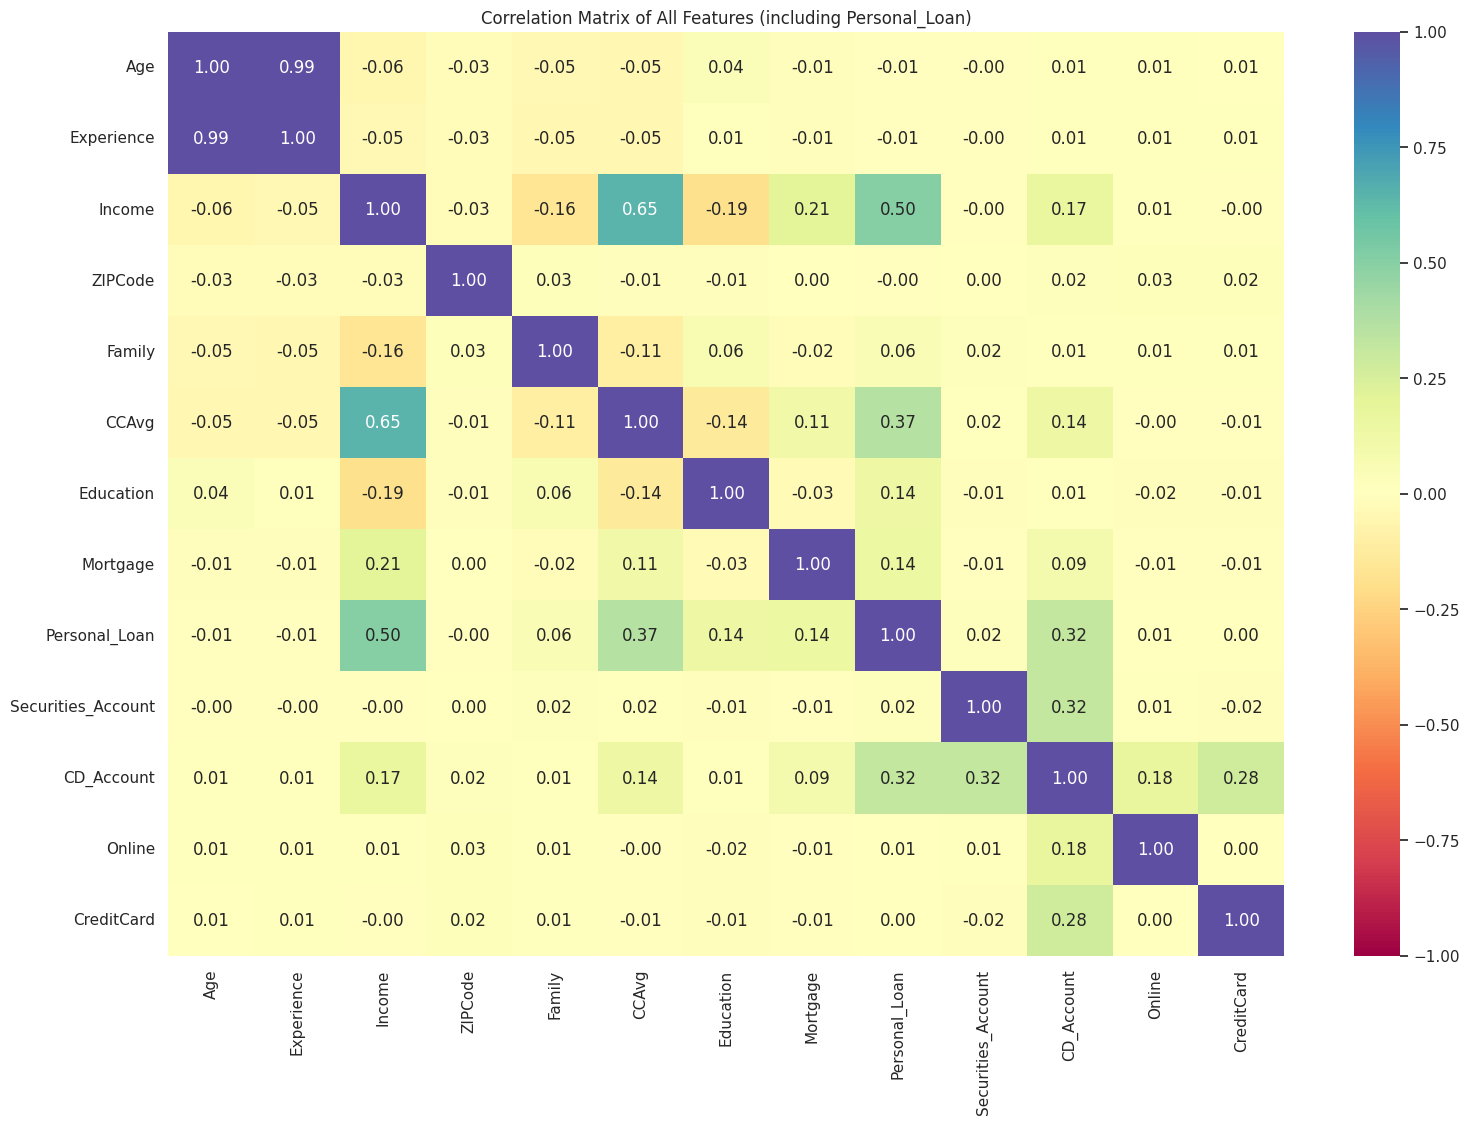

In [ ]:
#Lets plot all variables to see if we are missing any relationships.
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.title("Correlation Matrix of All Features (including Personal_Loan)")
plt.show()

### Observations for all variables:

From the correlation heatmap, we can observe the following relationships with `Personal_Loan` and among other features:

**Correlations with `Personal_Loan` (Target Variable):**

-   **Income:** Shows the strongest positive correlation with `Personal_Loan` (0.50). This confirms the observation from the box plots that higher income significantly increases the likelihood of accepting a personal loan.

-   **CCAvg (Average spending on credit cards per month):** Has a moderate positive correlation with `Personal_Loan` (0.37). This suggests that customers who spend more on credit cards are more likely to accept a personal loan.

-   **Education:** this have a moderate positive correlation with `Personal_Loan` (0.14). This indicates that higher education levels are associated with a greater chances to accept personal loans.

-   **CD_Account (Certificate of Deposit Account):** Shows a moderate positive correlation with `Personal_Loan` (0.32). Customers with a CD account are more likely to accept personal loans, possibly indicating a higher level of trust or engagement with the bank's financial products.

-   **Mortgage:** Has a weak positive correlation (0.00) with `Personal_Loan`.

-   **Family:** Shows a very weak positive correlation (0.01) with `Personal_Loan`.

-   **Securities_Account, Online, CreditCard, Age, Experience:** These attributes shows very weak correlation with `Personal_Loan` (correlations close to 0).

**Inter-feature Correlations:**

-   **Age and Experience:** As we see again that, `Age` and `Experience` are highly positively correlated (0.98), stating that experience generally increases with age.

-   **Income and CCAvg:** Have a moderate positive correlation (0.50), indicating that customers with higher incomes tend to spend more on credit cards.
-   **Income and Mortgage:** Have a moderate positive correlation (0.23), suggesting that higher-income individuals are more likely to have a mortgage or higher mortgage values.

-   **Education and Income:** Show a weak positive correlation (0.15).

**Good Predictors of Target varibale:**

-   `Income`, `CCAvg`, and `CD_Account` are the most positively correlated features with `Personal_Loan` and are likely to be strong predictors.

-   `Age` and `Experience` are highly correlated with each other, but not strongly with `Personal_Loan` individually.

-   The low correlations of many other features(Securities_Account, Online, CreditCard, Mortgage, family) with `Personal_Loan` suggest that the target variable might be influenced by a combination of factors.

## Data Preprocessing

### Checking for missing values

In [ ]:
# checking missing values
display(df.isnull().sum())

,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0
Securities_Account,0


**Observations from Missing Value Treatment:**

- The output above shows the count of missing values for each column. Based on this, we can conclude that there are no mising values to be treated by imputation with appropriate values.

In [ ]:
#As we see earlier, we have negative experience values. we can check what data have those negative values and will impute those data set with good number.
# first identify and count how many such entries exist in the dataset
negative_experience_data = df[df['Experience'] < 0]

negative_experience_count = df[df['Experience'] < 0].shape[0]

print(f"Number of rows with negative 'Experience': {negative_experience_count}")
print(f"Percentage of rows with negative 'Experience': {(negative_experience_count / len(df)) * 100:.2f}%")

Number of rows with negative 'Experience': 52
Percentage of rows with negative 'Experience': 1.04%


In [ ]:
#first we need to find out the good Medain value to impute based on the valid data set.
# Calculate 'Age_at_start_of_experience' for customers where 'Experience' is non-negative
valid_age_at_start = df[df['Experience'] >= 0]['Age'] - df[df['Experience'] >= 0]['Experience']

# Find the median of these valid_age_at_start values
median_age_at_start = valid_age_at_start.median()
median_age_at_start

25.0

In [ ]:
#For all rows where 'Experience' is negative,
# we will update the 'Experience' column
#  by calculating df['Age'] - median_age_at_start,
# even after subtracting median age  from age if we get any negative values there , then will replace them 0. ensuring non-negative values
df.loc[df['Experience'] < 0, 'Experience'] = np.maximum(0, df.loc[df['Experience'] < 0, 'Age'] - median_age_at_start)

print(f"Corrected negative 'Experience' values using median Age_at_start_of_experience: {median_age_at_start:.2f}")

Corrected negative 'Experience' values using median Age_at_start_of_experience: 25.00


In [ ]:
df['Experience'].describe()

,Experience
count,5000.000000
mean,20.122800
std,11.435361
min,0.000000
25%,10.000000
50%,20.000000
75%,30.000000
max,43.000000


In [ ]:
negative_experience_data_after_impute = df[df['Experience'] < 0]

negative_experience_data_after_impute_count = df[df['Experience'] < 0].shape[0]

print(f"Number of rows with negative 'Experience': {negative_experience_data_after_impute_count}")

print(f"Percentage of rows with negative 'Experience': {(negative_experience_data_after_impute_count / len(df)) * 100:.2f}%")

Number of rows with negative 'Experience': 0
Percentage of rows with negative 'Experience': 0.00%


Now all the negative experience data is imputed properly with no negative values in Experience Column

### Outlier Detection and Treatment

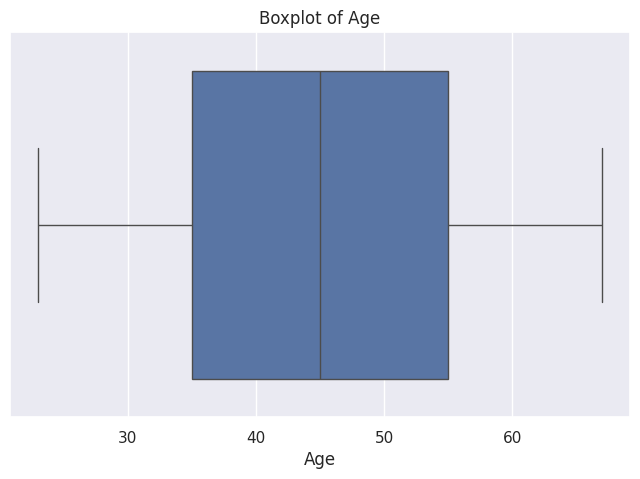

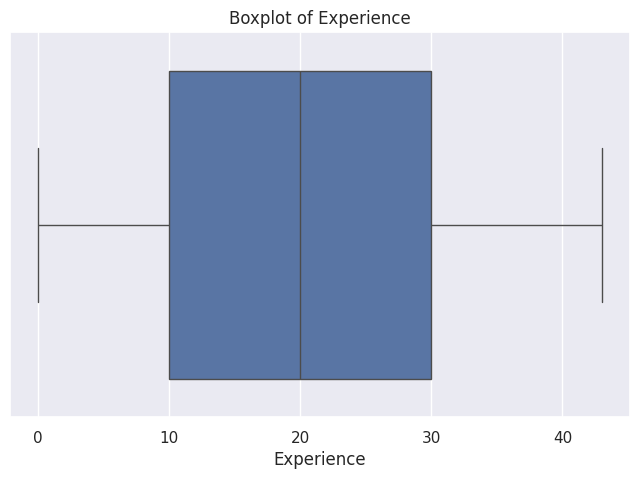

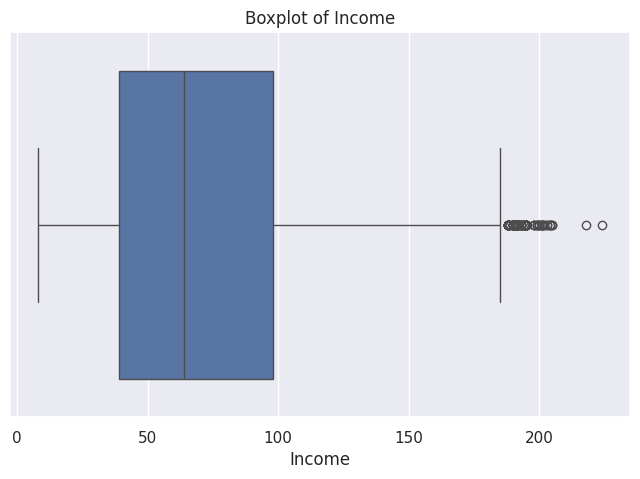

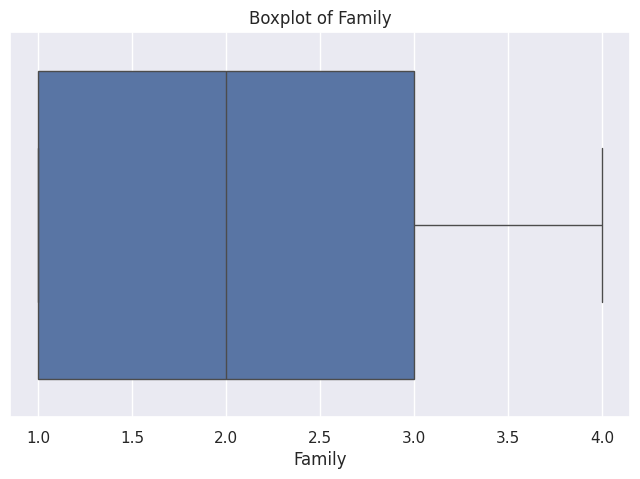

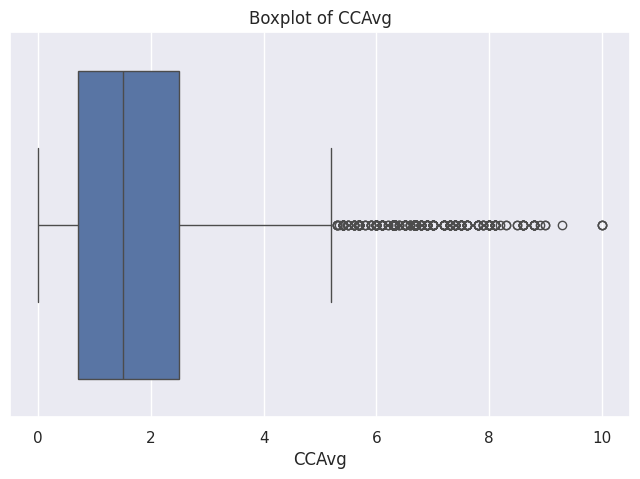

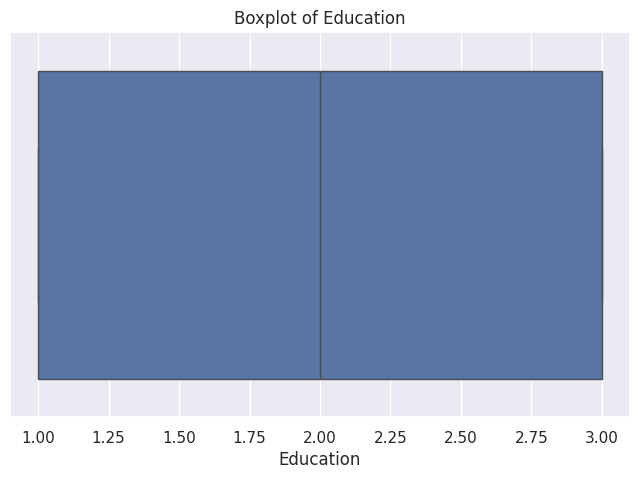

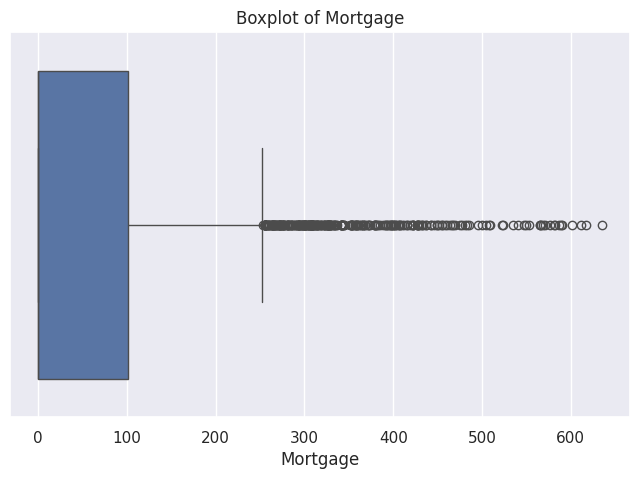

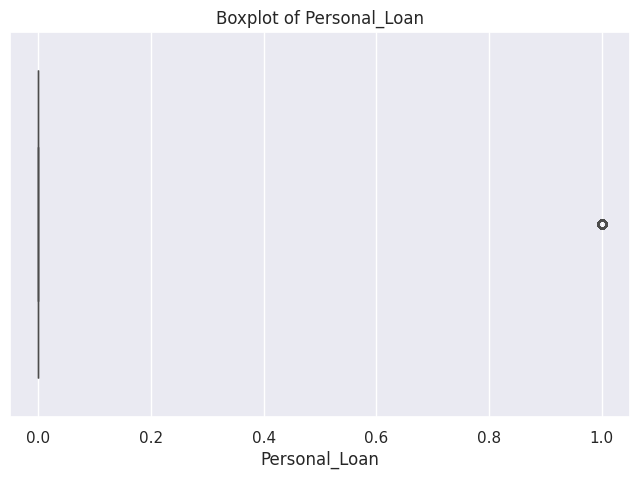

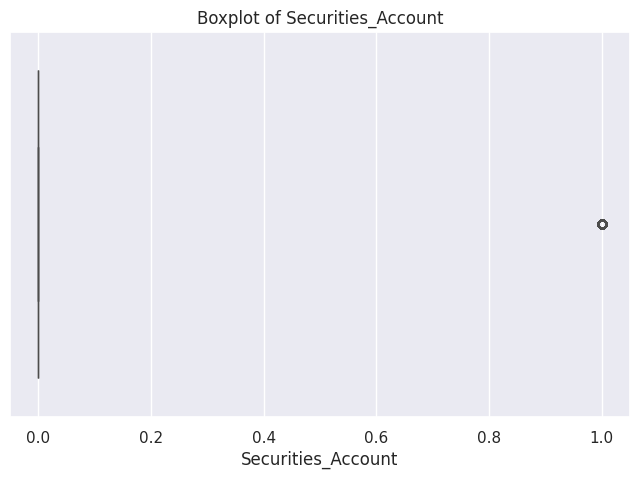

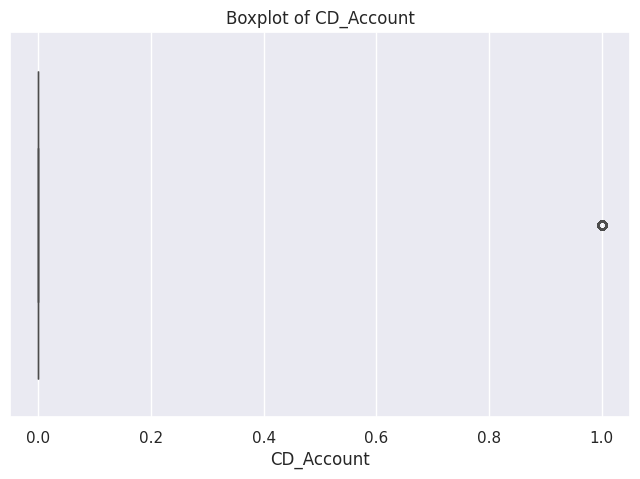

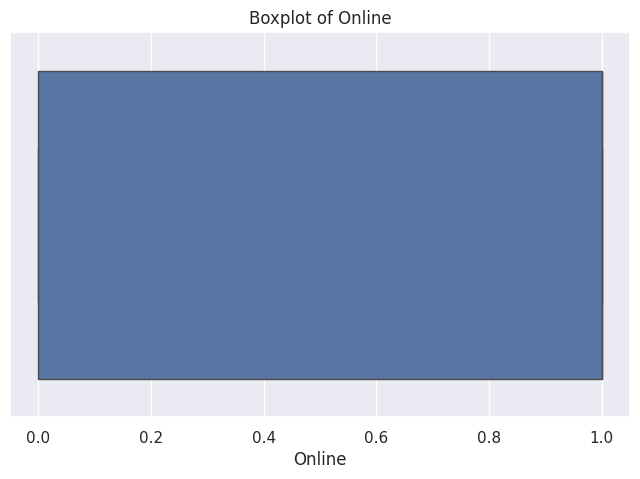

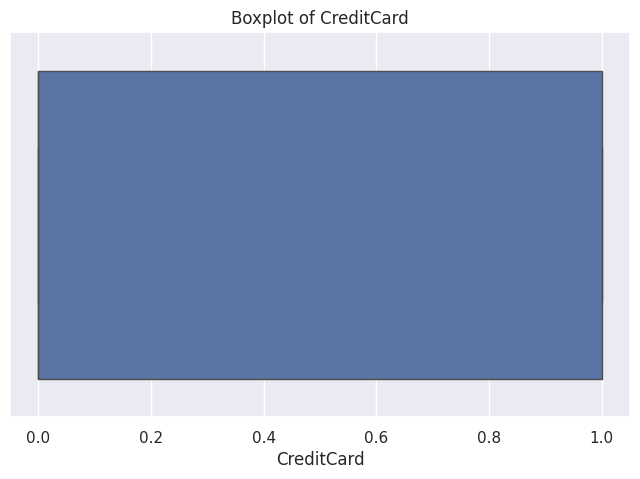

In [ ]:
# Outlier detection using boxplots for numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
columns_to_exclude = ["ZIPCode"]
num_cols_for_outliers = [col for col in numeric_columns if col not in columns_to_exclude]


for col in num_cols_for_outliers:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show();

**Observations from Outlier Detection (Boxplots):**

Based on the boxplots:

- **Age , Experience:** The Age and Experience distribution appears to be relatively symmetrical with no significant outliers.

- **Income:** The Income distribution is right-skewed, and the boxplot clearly shows us a significant number of outliers on the higher end of the income scale above around 170k dollars.
- **Family:** The Family size distribution appears to be without significant outliers.
- **CCAvg:** The CCAvg distribution is also heavily right-skewed, and the boxplot indicates the presence of several outliers with very high credit card spending averages.
- **Education:** As a categorical variable, a boxplot isn't the most appropriate visualization for outliers. We should rely on frequency counts or bar plots for this attribute.
- **Mortgage:** The Mortgage value is highly right-skewed, and the boxplot shows a large number of outliers with high mortgage values. Many customers have a mortgage value of 0.


* There are quite a few outliers in the data.
* However, we will not treat them as they are proper values.

In [ ]:
df.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### Feature Engineering
We dont need the additional features that can be derived from existing ones as we have features which are useful and can be used directly.

### Data Preparation for Modeling

In [ ]:
#set Random State
RS=1

X = df.drop(["Personal_Loan"], axis=1)
y = df["Personal_Loan"]


# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RS
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 12)
Shape of test set :  (1500, 12)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


**Observations**:

We had seen that around 90.5% of observations belongs to class 0 (Not accepting Personl Loan) and around 9.4% observations belongs to class 1 (Accept Personl Loan), and this is the same observed in test set as well.

So we can see that there is a data imbalance, targeted data where customers puchasing the personal Loan is very low. To avoid the data imbalance, we need to balance the data by adding weights technique.

## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**
- Predicting a customer will not purchase personal loan but in reality, the customer will purchase (FN).
- Predicting a customer will purchase the personal loan but in reality, the  customer will not purchase personal loan (FP).

**False Negatives (FN):**

The model predicts that a customer will not purchase a personal loan, but in reality, they would have purchased it if targeted.

***Impact***:  The bank misses an opportunity to acquire a new loan customer. This is a missed business opportunity case  and  also have a loss of interest/revenue from that loan.

***Suggestion***: Missing a customer (FN) is generally have less impact than incorrectly targeting someone who won't convert or take a personal loan (FP), especially in a campaign with limited resources. Instead bank would still acquire some other customers who were correctly interested in.

**False Positives (FP):**

The model predicts that a customer will purchase a personal loan, but in reality, they will not.

***Impact***:  The bank wastes marketing resources (time, money, effort, and other resources) on a customer who is not interested at all for the loan. This increases the cost of the campaign without a gain in loan uptake.
It may also disturb customers who are repeatedly targeted/called for offers they don't want.

***Suggestion***: To reduce False Positives, the bank should focus on improving the precision of the model. This means being more confident that a customer predicted to take a loan will actually do so.
Strategies could include refining the features used in the model, trying different model algorithms, or adjusting the model's prediction threshold.

**Which case is more important?**

In this scenario, **minimizing False Positives (FP)** is more important for the bank rather than False Negatives(FN) because of below reasons:

**Resource Allocation:** Marketing campaigns have budgets and limited resources. Spending these resources on customers who are unlikely to convert is inefficient and its costly to the bank.

**Customer Satisfaction:** Repeatedly targeting not interested customers can lead to negative customer experiences and it may harm the bank's relationship with them.

**Campaign Efficiency:** A high number of False Positives can make the campaign less successful than expected and make it difficult to accurately measure the true conversion rate.

Also reducing False Negative cases is also needed to maximize loan purchses.



In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("Actual label")
    plt.xlabel("Predicted label")

### Decision Tree (default)

In [ ]:
model_default = DecisionTreeClassifier(random_state=RS)
model_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

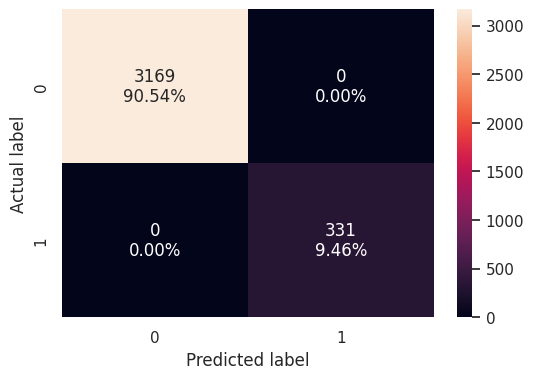

In [ ]:
confusion_matrix_sklearn(model_default, X_train, y_train)

In [ ]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model_default, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


From the above performance metris for default Decision tree, we see that all the metrics are 100% which means the model is overfitting on Train data set.

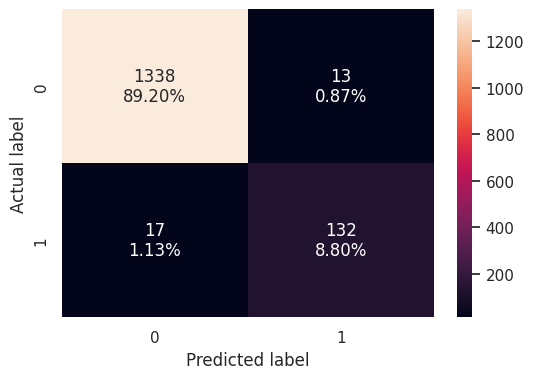

In [ ]:
confusion_matrix_sklearn(model_default, X_test, y_test)

In [ ]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model_default, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.98,0.885906,0.910345,0.897959


On the Test data, we see the merics good, so our model is generalizng well on test data.





In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 12)
Shape of test set :  (1500, 12)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


### Decision Tree (with class_weights)

* From the above percents of data points in both test and train set, we see that the frequency of class 0 is around  90.5% and the frequency of class 1 is around 9.4% in both train set and frequency of class 0 is around  90% and the frequency of class 1 is around 9.9%  test sets.

Then class 0 will become more dominant class and the decision tree will become biased toward the dominant classes

* In this case, we will set class_weight = "balanced", which will automatically adjust the weights to be inversely proportional to the class frequencies in the input data

* class_weight is a hyperparameter for the decision tree classifier

In [ ]:
model_with_weights = DecisionTreeClassifier(random_state=1, class_weight="balanced")
model_with_weights.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

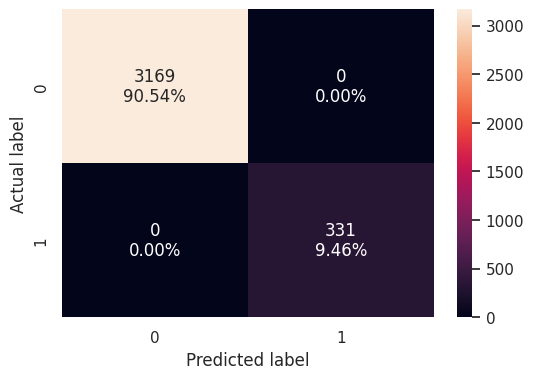

In [ ]:
confusion_matrix_sklearn(model_with_weights, X_train, y_train)

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model_with_weights, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* Model is able to perfectly classify all the data points on the training set.
* 0 errors on the training set, each sample has been classified correctly.
* Eventhough we applied weights to balance the dataset, still we see the overfitting on Training data.

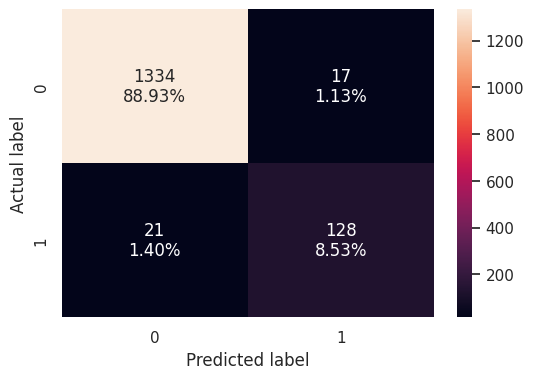

In [ ]:
confusion_matrix_sklearn(model_with_weights, X_test, y_test)

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model_with_weights, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.974667,0.85906,0.882759,0.870748


* There is a huge difference in performance of model when we look at F1 Scores on training set(100%) and test set(87%), which suggests that even we apply class_weight='balanced' without any pruning done, the model is overfiiting.

* This model didnt improve test performance or reduce overfitting compared to the default model.

#### Visualizing the Decision Tree

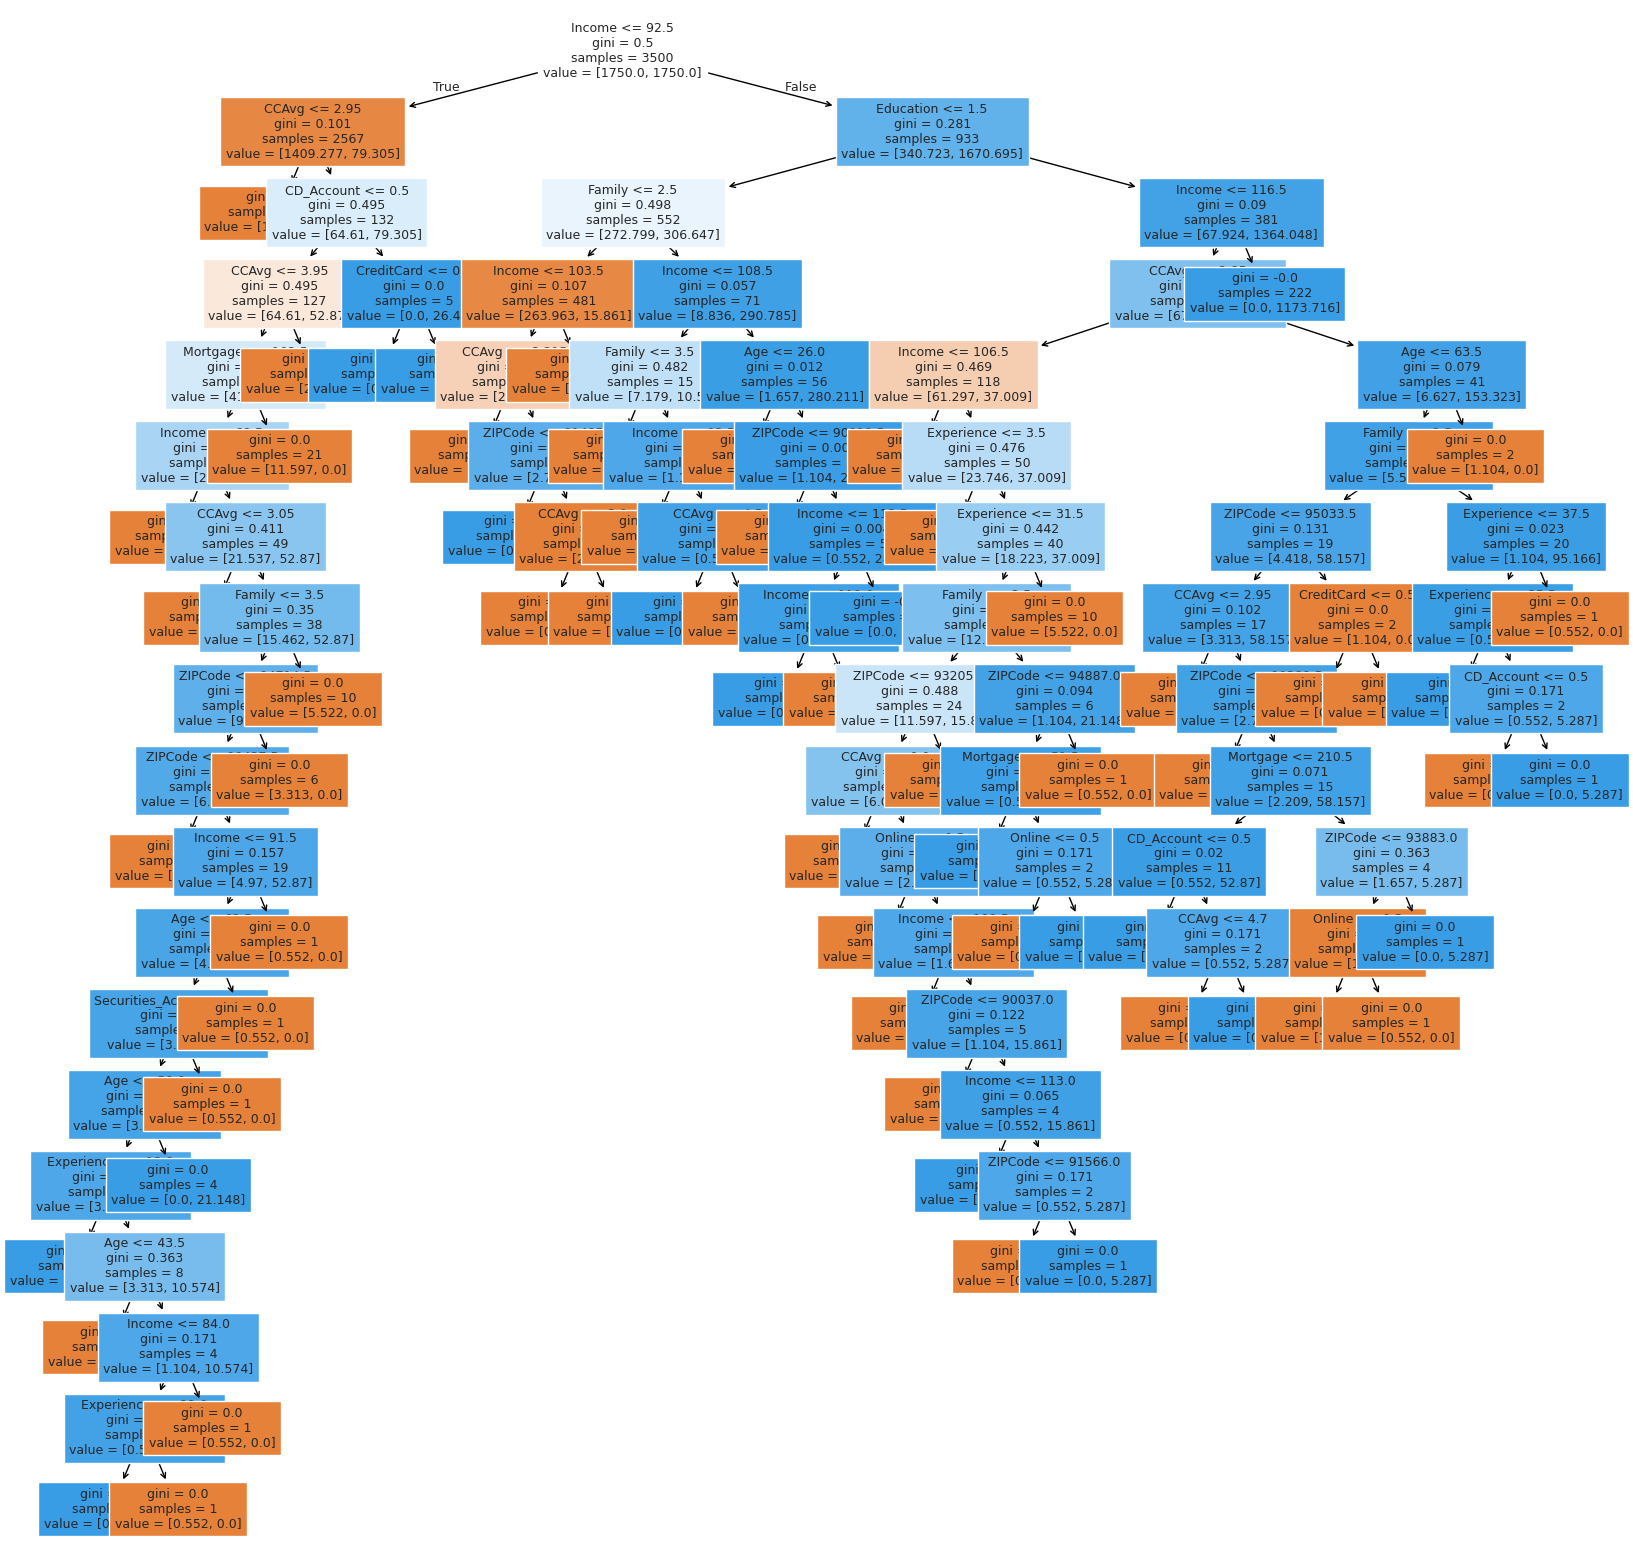

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model_with_weights,            # decision tree classifier model with weights
    feature_names=feature_names,   # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- We can observe that this is a very complex tree which has grown a lot and learnt the noise a lot in training set.

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        model_with_weights,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- Mortgage <= 102.50
|   |   |   |   |   |--- Income <= 68.50
|   |   |   |   |   |   |--- weights: [8.28, 0.00] class: 0
|   |   |   |   |   |--- Income >  68.50
|   |   |   |   |   |   |--- CCAvg <= 3.05
|   |   |   |   |   |   |   |--- weights: [6.07, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  3.05
|   |   |   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |   |   |--- ZIPCode <= 94714.50
|   |   |   |   |   |   |   |   |   |--- ZIPCode <= 90437.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [1.66, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- ZIPCode >  90437.50
|   |   |   |   |   |   |   |   |   |   |--- Income <= 91.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |   |   |   |   |   |   |--- Incom

**Let's Implement pruning techniques (Pre-pruning, Post-Pruning) and reduce overfitting.**

### Decision Tree (Pre-pruning)

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=RS
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [ ]:
# creating an instance of the best model
model_pre_pruned = best_estimator

# fitting the best model to the training data
model_pre_pruned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10, random_state=1)

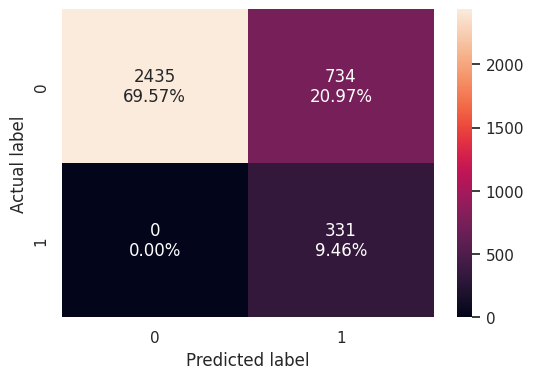

In [ ]:
confusion_matrix_sklearn(model_pre_pruned, X_train, y_train)

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model_pre_pruned, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.790286,1.0,0.310798,0.474212


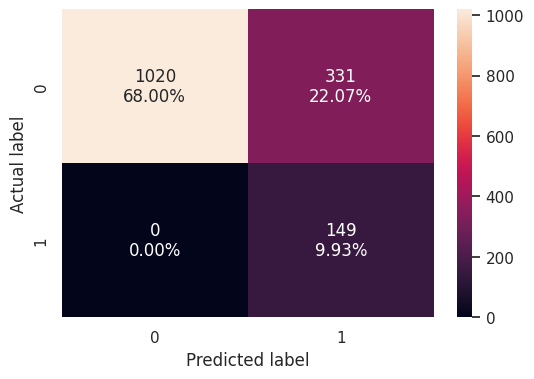

In [ ]:
confusion_matrix_sklearn(model_pre_pruned, X_test, y_test)

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model_pre_pruned, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.779333,1.0,0.310417,0.473768


**Observations**:

1. When we look at  the recall scores and Precision on both the train and test
sets, there is no much huge differences in all the metrics.

2. On Train data, we see the precision (for minimising the False positives in our case) is 31% on Train dataset and test data. There is no difference between both test and train data sets.

3. Similary for Recall (for minimising False Negative cases), we see 100% on training set and  Test data.

4. F1 Scores are also ranging around 47%.

5. So in pre-pruning model, we see that metrics are not that good, they are less than 60% atleast. So we may be missing any other important feature in pre-pruing.

6. There's a significant drop in
Accuracy(from 98-100% to it got dropped to around 77%) and
F1-score(from 89-100% to it got dropped to around 47%) compared to the unpruned models.

7. The Recall is 1.0, meaning it correctly identifies all positive cases in the training set, but at the cost of very low Precision.

8. This suggests that the model is classifying many negative cases as positive (high False Positives) to achieve high recall, indicating it might be too generalized.

so lets see post pruning method and see how scores are.



In [ ]:
feature_names = list(X_train.columns)
importances = model_pre_pruned.feature_importances_
indices = np.argsort(importances)

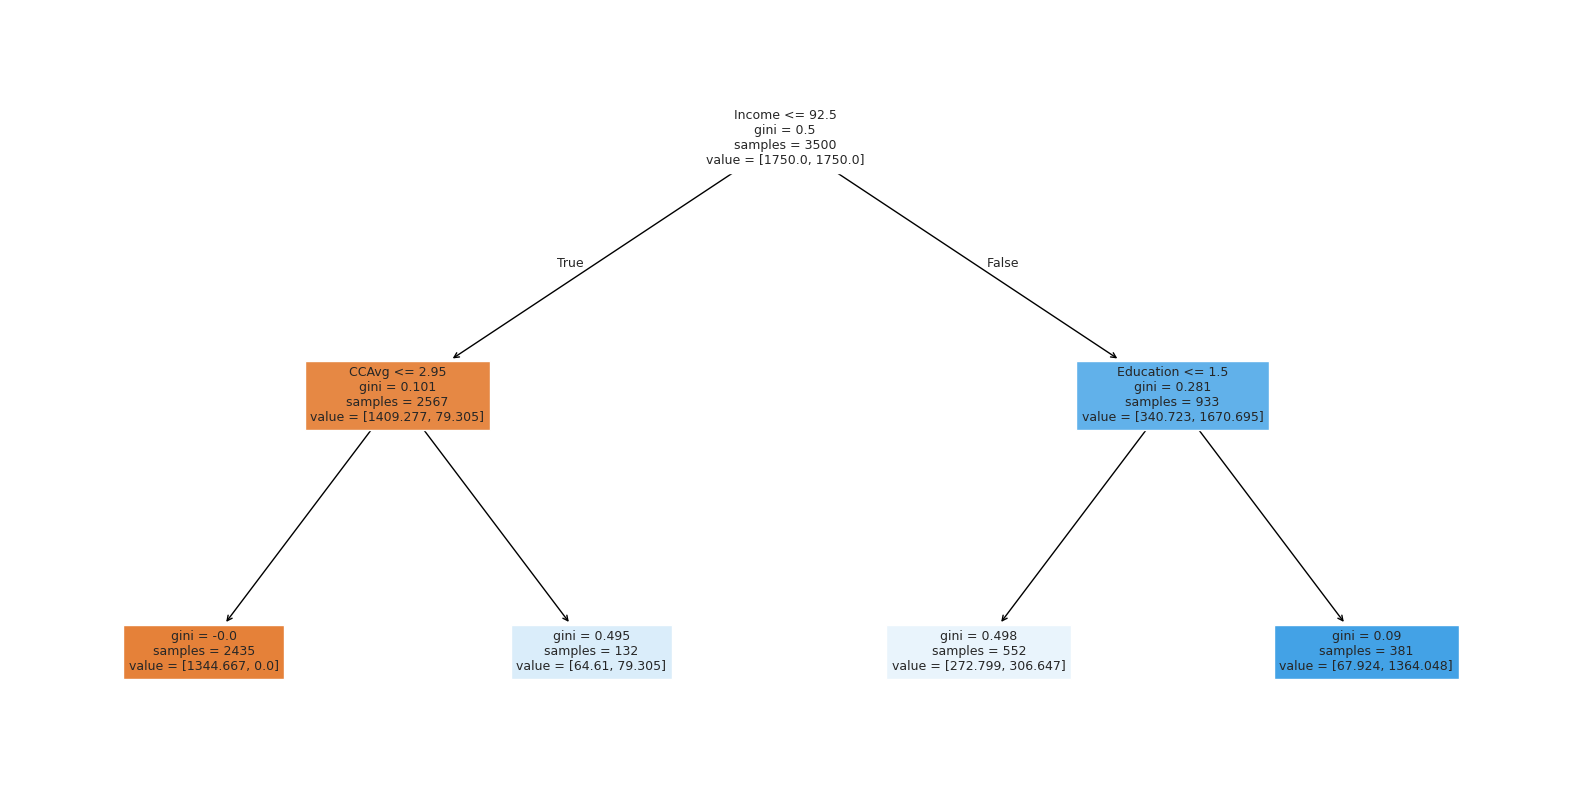

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model_pre_pruned,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()


In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model_pre_pruned, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [64.61, 79.31] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- weights: [272.80, 306.65] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [67.92, 1364.05] class: 1



In [ ]:
importances = model_pre_pruned.feature_importances_
importances

array([0.        , 0.        , 0.82007181, 0.        , 0.        ,
       0.06262835, 0.11729984, 0.        , 0.        , 0.        ,
       0.        , 0.        ])

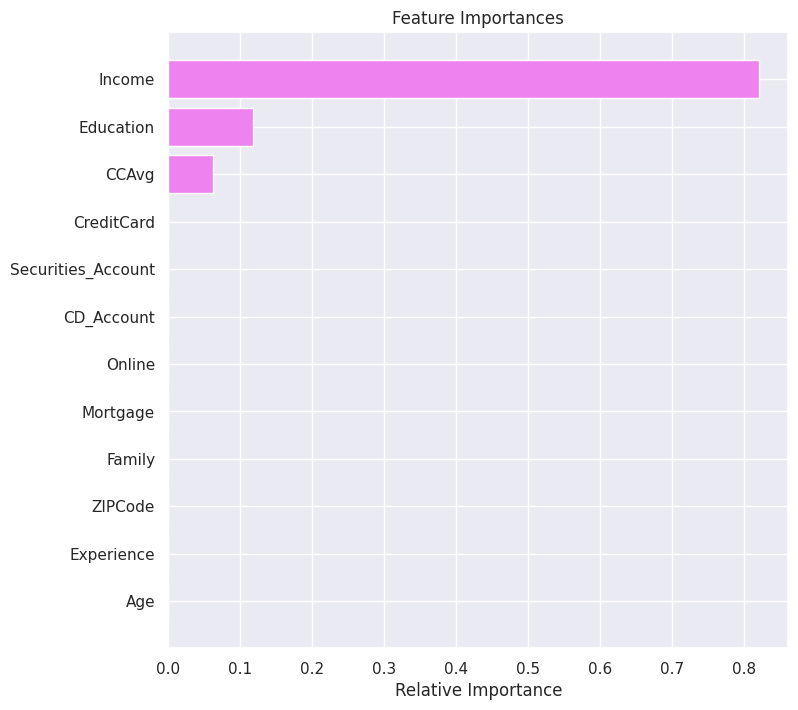

In [ ]:
# importance of features in the tree building

importances = model_pre_pruned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* In the pre-pruned decision tree, we see these are the important features:  Income, Education and CCAvg score.

### Decision Tree (Post pruning)

In [ ]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=RS, class_weight="balanced")

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-9.196446e-15
1,4.729571e-19,-9.195973e-15
2,5.255079e-19,-9.195447e-15
3,1.051016e-18,-9.194396e-15
4,1.257806e-17,-9.181818e-15
5,1.524700e-04,3.049400e-04
6,1.537634e-04,6.124667e-04
7,1.561475e-04,9.247618e-04
8,1.568682e-04,1.238498e-03
9,1.574681e-04,1.553435e-03


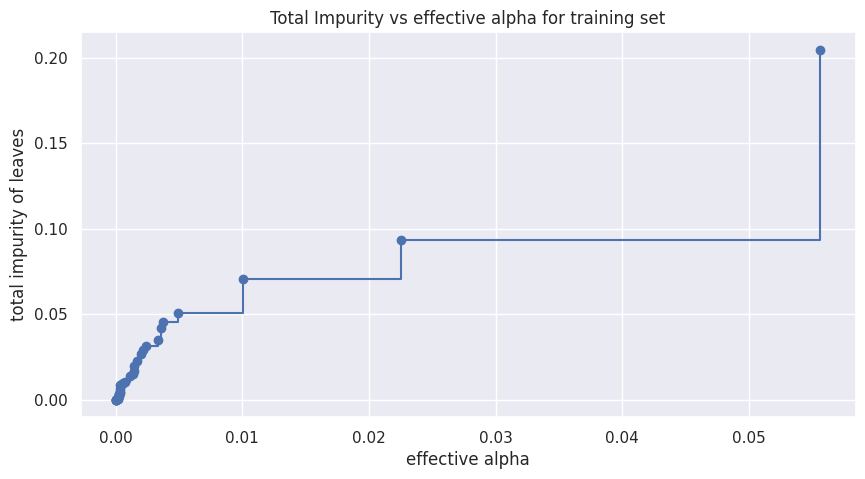

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=RS, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.2953792759992316


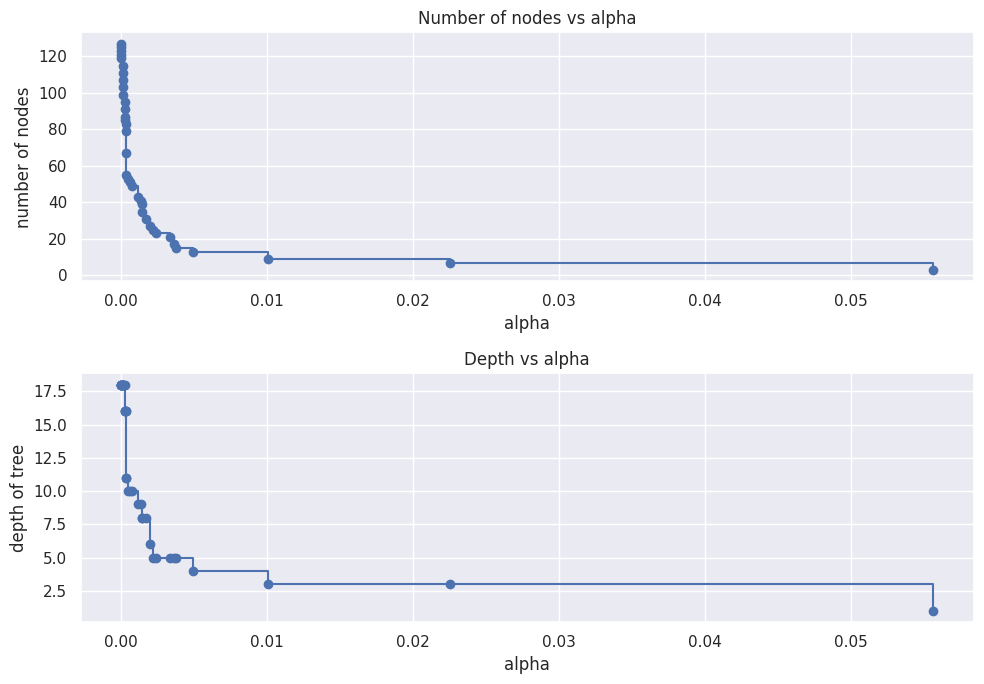

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")

fig.tight_layout()

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

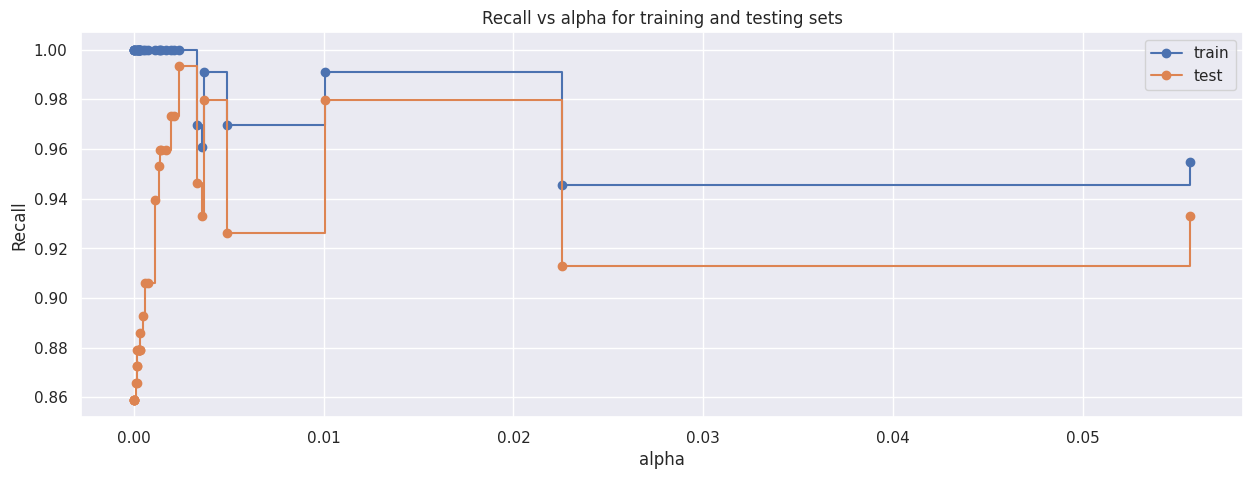

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.002375808619774645),
                       class_weight='balanced', random_state=1)


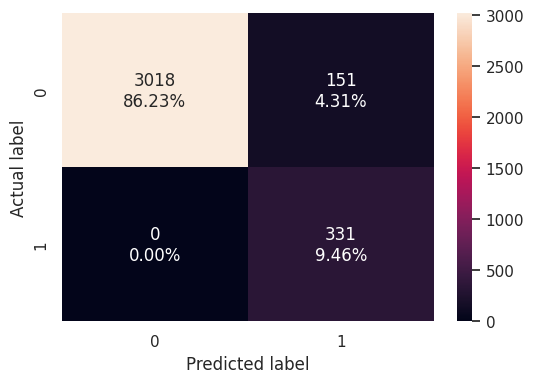

In [ ]:
model_post_pruned = best_model
confusion_matrix_sklearn(model_post_pruned, X_train, y_train)

In [ ]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model_post_pruned, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.956857,1.0,0.686722,0.814268


**Observation on train data**:
Post-pruning significantly improves Precision and F1-score compared to pre-pruning while maintaining perfect Recall on the training set.

This shows a better balance and reduced overfitting compared to the default models.

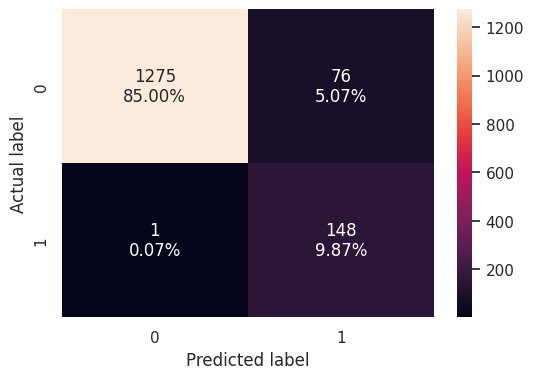

In [ ]:
confusion_matrix_sklearn(model_post_pruned, X_test, y_test)

In [ ]:
decision_tree_post_test = model_performance_classification_sklearn(
    model_post_pruned, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.948667,0.993289,0.660714,0.793566


**Observation on Test data:**

The test performance is very close to the training performance, indicating the model is able to generalize well on unseen data.

The high Recall (0.993) means it identifies almost all potential loan customers.

The Precision (0.661) is much better than pre-pruning, implying fewer wasted marketing efforts.

The F1-score (0.794) is robust and suggests a good balance between Precision and Recall for the minority class.

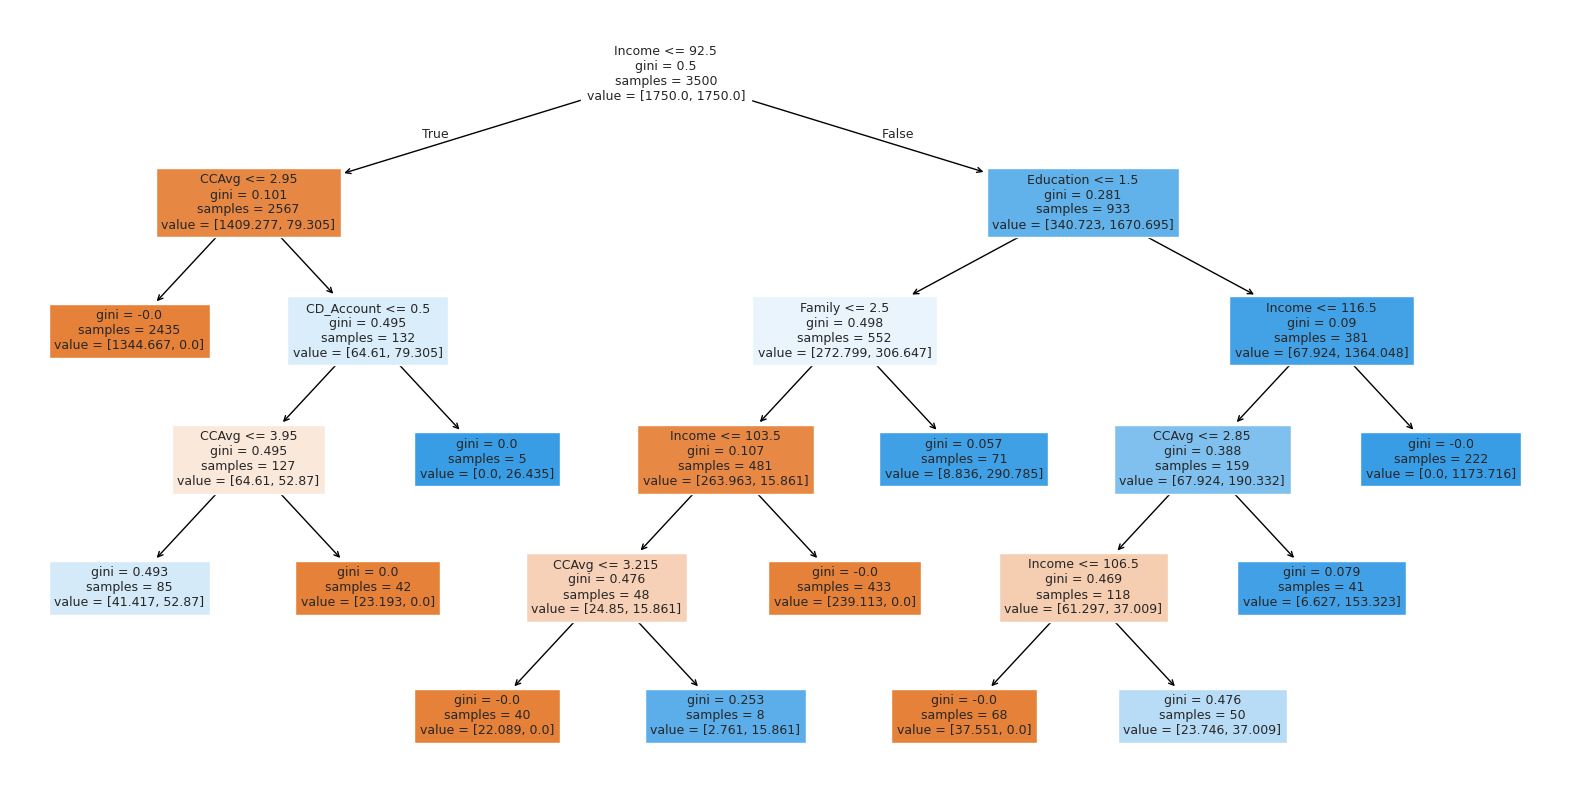

In [ ]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model_post_pruned,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model_post_pruned, feature_names=feature_names, show_weights=True))


|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [41.42, 52.87] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [23.19, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.00, 26.44] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 103.50
|   |   |   |   |--- CCAvg <= 3.21
|   |   |   |   |   |--- weights: [22.09, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.21
|   |   |   |   |   |--- weights: [2.76, 15.86] class: 1
|   |   |   |--- Income >  103.50
|   |   |   |   |--- weights: [239.11, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [8.84, 290.79] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- CCAvg <= 2.85
|   |   |   |   |--- Income <= 106.50
|   |   |   |   | 

In [ ]:
importances = model_post_pruned.feature_importances_
indices = np.argsort(importances)

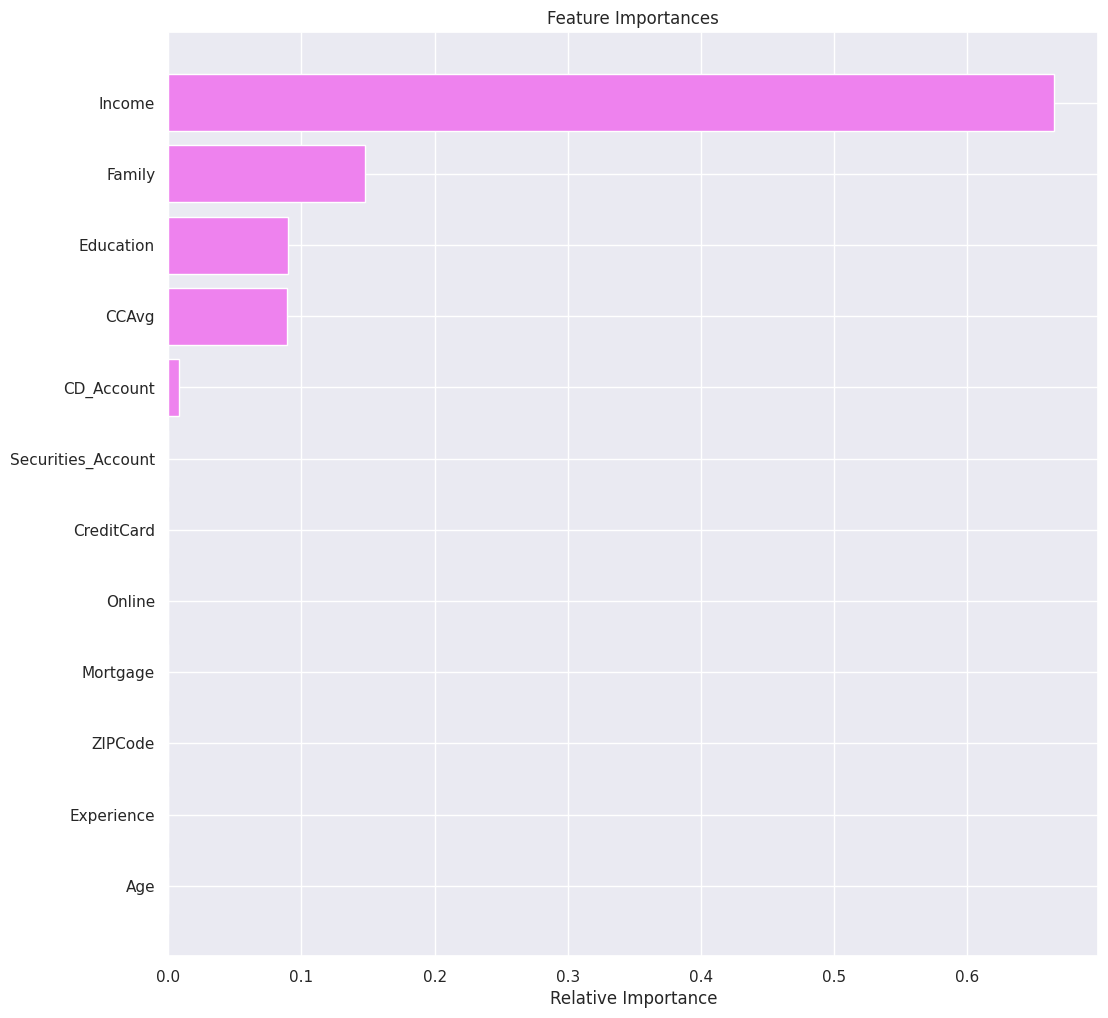

In [ ]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- In post pruning , along with attributes in pre-pruning model(Income, Education and  CCAvg), Family, CD_Account  are also one of  the most important features.

## Comparison of Models and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.790286,0.956857
Recall,1.0,1.0,1.000000,1.000000
Precision,1.0,1.0,0.310798,0.686722
F1,1.0,1.0,0.474212,0.814268


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.980000,0.974667,0.779333,0.948667
Recall,0.885906,0.859060,1.000000,0.993289
Precision,0.910345,0.882759,0.310417,0.660714
F1,0.897959,0.870748,0.473768,0.793566


**Observations**:
* In Pre-pruned model, we see the metrics Recall(100%), Precesion(31%), F1 Score(47%) which are very low. This indicates that we may be missing an another important feature in the data by pre-pruning the tree and there is no good balance between Recall and Precision. we still have many False Positive cases.

* The Post-pruned Decision Tree, given its high Recall (0.993) and significantly improved Precision (0.661) and F1-score (0.794) on the test set, offers the best balance for a marketing campaign aimed at identifying potential loan customers while managing marketing costs effectively.

* We see good Recall Score on test set, which means there are very minimum False Negative cases which is greatly reducing the revenue loss to the bank by lossing the potential customers who will take loan actully but model peredicted them as they wont.

* Therefore, we can choose the Post-pruned model as our best model.

## Business Insights and Recommendations

Based on the rules identified in the post-pruned Decision Tree, the bank can implement targeted marketing strategies to convert liability customers into personal loan customers.The most influential features are `Income`, `Education`, `CCAvg`, `CD_Account`, and `Family` size.

Recommendations based on different criteria rules from post-pruned tree:

1.  **High-Income Customers with High Credit Card Spending and CD Accounts:**
    *   **Criteria:** `Income > 92.50 AND Education > 1.50 AND CCAvg > 2.85` often leads to loan acceptance. Also, `Income <= 92.50 AND CCAvg > 2.95 AND CD_Account > 0.50` is a strong indicator.

    *   **Recommendation:** Target customers with high income (e.g., over $92,500), significant credit card spending (e.g., CCAvg over $2,850/month), and especially those who already have a CD Account. These segments show a very high propensity to accept personal loans.

    *   **Actions:**
        *   Offer pre-approved personal loans with competitive interest rates and flexible repayment options to this group.
        *   Personalized outreach through relationship managers or exclusive digital channels, highlighting how a personal loan can complement their existing financial portfolio or help consolidate other debts.
        *   Emphasize benefits like quick disbursal and minimal documentation.

2.  **Educated Individuals with Moderate to High Income:**
    *   **Criteria:** `Income > 92.50 AND Education > 1.50` (Graduate or Advanced/Professional Education) is a crucial split, indicating higher loan acceptance for this group.
    *   **Recommendation:** Focus marketing efforts on customers with higher education levels, as they are more likely to accept personal loans, particularly if their income is also above a certain threshold.
    *   **Actions:**
        *   Tailor marketing messages to highlight how personal loans can support professional development, higher education expenses for family, or lifestyle upgrades, resonating with their educational background.
        *   Collaborate with professional associations or alumni networks for targeted campaigns.

3.  **Customers with High Credit Card Spending (CCAvg):**
    *   **Criteria:** `CCAvg > 2.95` frequently appears early in the decision paths leading to loan acceptance, especially for those with lower incomes but CD Accounts.
    *   **Recommendation:** Customers with high average monthly credit card spending are good candidates, as they might be looking for ways to consolidate debt or manage expenses more efficiently.
    *   **Actions:**
        *   Promote personal loans as a credit card debt consolidation tool, potentially offering lower interest rates than their existing credit cards.
        *   Run campaigns specifically addressing credit management and financial planning, positioning personal loans as a solution.

4.  **Customers with CD Accounts:**
    *   **Criteria:** `CD_Account > 0.50` (having a CD account) is a strong positive indicator, even for some lower-income segments. This suggests a higher trust and engagement with the bank.
    *   **Recommendation:** Leverage existing relationships with customers who hold CD accounts. They demonstrate a higher level of financial commitment to the bank and are more receptive to loan offers.
    *   **Actions:**
        *   Cross-sell personal loans to CD account holders through in-branch promotions, dedicated online portal messages, and email campaigns.
        *   Offer loyalty bonuses or preferred rates on personal loans to CD account holders.

5.  **Consideration of Family Size:**
    *   **Criteria:** `Family > 2.50` (family size 3 or 4) appears as a segment with higher loan acceptance for certain income and education groups.
    *   **Actions:**
        *   Tailor loan products or marketing to address family-related expenses (e.g., education, home improvements, medical costs) for customers in identified family size segments.